<a href="https://colab.research.google.com/github/Clover130/u8229609-Individual-Project/blob/main/EMSC2010_Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Project: Groundwater Modelling in the Murray Darling Basin

## Research Question

Which climatic factor (rainfall, temperature, evaporation or evapotranspiration) is the most significant predictor of groundwater level fluctuations?

Can a simple data-driven water balance model reproduce observed groundwater level fluctuations and be used to investigate future climate and pumping scenarios?


## Scope

This project draws from data of a specific bore: GW030450, located in the Lower Namoi Groundwater Catchment region (Northern NSW). The bore is a shallow unconfined monitoring bore with 50 years of record (DCCEEW, 2025).

An unconfined aquifer is a permeable layer of rock, sand or gravel whose upper boundary is the water table (ie. no pearmeable layer above so water is able to rise and fall in direct contact to atmosphere). Hence this site is ideal for this project as its fluctuations will be correlated to climactic factors.

Groundwater level fluctuates due to the balance between recharge (primarily rainfall infiltration) and discharge (evapotranspiration, evaporation and extraction), making a simple water balance appropriate for this project. The model is intended to identify broad trends and relative climate influences rather than produce accurate short term results, however it will provide a physically interpretable link between climate factors and the groundwater response. Additionally focusing on a simplistic model allows for future climate and pumping scenarios to be explored.

## Background Information

Groundwater in the Lower Namoi is under sustained pressure from agricultural extraction and climate variability. As part of the Upper Murray-Darling Basin, the Lower Namoi alluvial aquifer supplies irrigation water to one of NSW's most productive agricultural regions. The Lower Namoi hydrogeological conceptual model report (DCCEEW, 2025) confirms groundwater levels have been declining, particularly in the Wee Waa area. It is important to understand if these changes are driven by climate or extraction.

The Millennium Drought was a prolonged period of drought conditions (below average rainfall and increased temperatures) in Australia from 1997 to 2009. It had significant impacts on streamflow, soil moisture and groundwater storage across the Murray-Darling Basin. Because this data set spans the Millennium Drought period it provides a natural scenario from which the groundwater response to climactic stresses can be investigated. And importantly it will also be used to test the ability for the simple model to reproduce climatic changes.

## Sources

(DCCEEW, 2025)

*Lower Namoi Hydrogeological Conceptual Model Report (Sponsored by the Murray Darling Basin Authority)*, Nov 2025, Department of Climate Change, Energy, the Environment and Water, <https://www.mdba.gov.au/sites/default/files/publications/SY%20Lower%20Namoi%20hydrogeological%20conceptual%20model%20report.pdf>.

- used for selecting bore and establishing background information

## Datasets

BOM National Groundwater Explorer (NGIS):
Bureau of Meteorology, National Groundwater Information System, Australian Groundwater Explorer, accessed May 2026, https://www.bom.gov.au/water/groundwater/explorer/


SILO Climate Data for Wee Waa:
Queensland Government, LongPaddock SILO Point Data, Australian climate data from 1889 to yesterday, accessed May 2026, https://longpaddock.qld.gov.au/silo/point-data/

- The sources are all free and openly accessible. Bore GW030450 from BOM NGIS includes 50 years of water level measurements, irregularly sampled that I've resampled to monthly means with linear interpolation for missing months.
- Climate data from SILO LongPaddock at the bore's coordinates includes daily rainfall, maximum temperature, FAO56 ET, and pan evaporation, aggregated to monthly totals or means.
- The 50-year overlap from 1974 to 2024 captures multiple drought and wet cycles including the Millennium Drought, which provides a strong natural experiment.


**Data Categories:**
- Groundwater: Reduced Standing Water Level (RSWL, in mAHD) is the water level expressed as an elevation above the Australian Height Datum (mean sea level = 0)

- Daily rainfall (mm)
- Maximum temperature (°C)
- Pan Evaporation (mm) estimates the amount of water that could be evaporated by an open water source, essentially an indicator of atmospheric evaporative demand
- Evapotranspiration FAO56 (mm) (from the UN Food and Agriculture Organisation Irrigation) estimates reference evapotranspiration: how much water a standardised short grass surface would lose given the local climate conditions. Hence it combines temperature, humidity, wind, and solar radiation into one variable
  - international standard in hydrology and groundwater studies
  - estimates potential ET under reference conditions (actual ET may be lower under drought scenarios)

**Limitations**

Groundwater dataset
- water level measurements collected at irregular intervals and required resampling to monthly averages, this introduces interpolation uncertainty
- analysis is based on a single monitoring bore which cannot not fully represent groundwater behaviour across the broader Lower Namoi aquifer
- groundwater levels are influenced by multiple processes including pumping, lateral groundwater flow and aquifer heterogeneity that are not directly measured in the dataset.

Climate Dataset
- SILO climate data are gridded products generated using interpolation between weather stations, hence may not perfectly represent local conditions at the bore
- FAO56 evapotranspiration represents potential evapotranspiration under standardised conditions rather than actual evapotranspiration
- climate variables were aggregated from daily to monthly timesteps
- correlations between climate variables (e.g. temperature and evapotranspiration) will introduce multicollinearity into regression analyses

**FAIR Principles: Groundwater Data**

Findability (F):
The groundwater data is published and maintained by the Bureau of Meteorology through the National Groundwater Information System (NGIS) and is discoverable via the Australian Groundwater Explorer interactive map at https://www.bom.gov.au/water/groundwater/explorer/map.shtml. Bore GW030450.1.2 can be located by searching the bore ID directly or by navigating to the Narrabri/Wee Waa region of NSW within the map interface.

Accessibility (A):
The data is freely accessible without requiring an account or login. Water level records can be viewed interactively through the explorer and exported manually as tabular data. All terminology and variable definitions are publicly documented at https://www.bom.gov.au/water/groundwater/explorer/terminology.shtml. The dataset used in this analysis is provided in the accompanying GitHub repository.

Interoperability (I):
The exported data follows a consistent tabular structure with clearly labelled columns (Bore ID, Date, Variable, Result (m), Quality Code, Agency) compatible with standard data tools including Python pandas. Dates are provided in a standard day/month/year format and the RSWL variable uses the nationally consistent Australian Height Datum (AHD), ensuring compatibility with other spatial and hydrological datasets across Australia.

Reusability (R):
All material on the Australian Groundwater Explorer is licensed under the Creative Commons Attribution 4.0 International Licence, meaning the data can be freely reused for research and education with appropriate attribution. Variable definitions follow nationally standardised terminology maintained by the NGIS.

**FAIR Principles: Silo Climate Data**

Findability (F):
SILO is a database of Australian climate data from 1889 to the present, developed by the Climate Projections and Services team within Queensland Treasury. The dataset is publicly listed and discoverable via the LongPaddock portal at https://longpaddock.qld.gov.au/silo/. Point data for any Australian location can be accessed directly through the Get Point Data interface at https://longpaddock.qld.gov.au/silo/point-data.

Accessibility (A):
Data are freely available from SILO without an account or login and can be downloaded in CSV format by entering the target coordinates and date range through the web interface or API. SILO climate data are available for primary and derived variables on a daily timestep over the period 1889–present. The dataset used in this analysis is provided in the accompanying GitHub repository.

Interoperability (I):
Data are provided in plain text CSV format with clearly labelled column headers using standardised short-name codes (e.g. daily_rain, max_temp, evap_pan, et_short_crop), directly compatible with Python pandas and numpy. Metadata describing the primary variables and the procedures used to construct them are available in the Queensland Spatial Catalogue. The FAO56 ET variable follows the internationally standardised Food and Agriculture Organisation Irrigation Paper 56 methodology, ensuring compatibility with global hydrological literature.

Reusability (R):
SILO climate data are freely available under the Creative Commons Attribution 4.0 International Licence. The data can therefore be freely shared and reused for research and education with appropriate attribution. However it should be noted that SILO uses mathematical interpolation techniques to construct spatial grids and infill gaps in time series datasets.

## Method
1. Set up research question, background and scope
2. Data import: extract and download data from sites above, resample to monthly timesteps and align into one data base over the common period (1974-2024)
3. Time series and frequency analyis: examine long term trends adn seasonal variability across the factors, then conduct cross correlation analysis to identify lag times and set a lagged data frame up for regression analysis
4. Regression analysis: simple regression to demonstrate the linear relationship, conduct multiple regression using the lagged variables, extract the standardised regression ceofficients to quantify the relative influence of each factor to be used in the modelling analysis
5. Water balance modelling: construct a simple water balance model with the regression coefficients factored into the recharge/discharge equations, calibrate model parameters, conduct scenario analysis (for the Millennium Drought, hypothetical pumping scenario and projected future climate/pumping scenarios)
6. Summarise key interpretation

This notebook has sequential flow with pop downs for each main section (Data Import, Time Series/Frequency Analysis, Regression, Modelling, Interpretation, Reflection) and smaller headings within the section that break down the method further - they should be followed in order.

## AI Use
To assist my understanding and ability to apply course content to this project I have used AI in places throughout, all are marked as being assisted by AI and any produced AI code has been modified to match my level of understanding and applicability to the project

# 2. Data Import

### 2.1 Load Data Files

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Data File Load
- requires files to be uploaded to the colab, attached in the repository

In [171]:
# Load groundwater data
gw_raw = pd.read_excel('groundwater_data_GW030170.1.1.xlsx',
                       sheet_name = 'Water Level (GW0301701.1)',
                       parse_dates=['Date'])

print("Columns:", gw_raw.columns.tolist())
print("Date dtype:", gw_raw['Date'].dtype)       # should say datetime64
print("Variables present:", gw_raw['Variable'].unique())  # should show DTW, RSWL, SWL
print(gw_raw.head(10))

# Load climate data
climate_raw = pd.read_csv('Wee_Waa_climate_data.csv', parse_dates=['YYYY-MM-DD'])
print("Columns:", climate_raw.columns.tolist())
print("Date dtype:", climate_raw['YYYY-MM-DD'].dtype)       # should say datetime64
print(climate_raw.head(10))

Columns: ['Bore ID', 'Date', 'Variable', 'Result (m)', 'Quality Code', 'Agency']
Date dtype: datetime64[ns]
Variables present: ['DTW' 'RSWL (mAHD)' 'SWL']
        Bore ID       Date     Variable  Result (m) Quality Code    Agency
0  GW030170.1.1 1972-01-24          DTW        8.33    quality-E  WaterNSW
1  GW030170.1.1 1972-01-24  RSWL (mAHD)      188.57    quality-E  WaterNSW
2  GW030170.1.1 1972-01-24          SWL        9.13    quality-E  WaterNSW
3  GW030170.1.1 1972-04-13          DTW        8.69    quality-E  WaterNSW
4  GW030170.1.1 1972-04-13  RSWL (mAHD)      188.21    quality-E  WaterNSW
5  GW030170.1.1 1972-04-13          SWL        9.49    quality-E  WaterNSW
6  GW030170.1.1 1972-05-18          DTW        8.91    quality-E  WaterNSW
7  GW030170.1.1 1972-05-18  RSWL (mAHD)      187.99    quality-E  WaterNSW
8  GW030170.1.1 1972-05-18          SWL        9.71    quality-E  WaterNSW
9  GW030170.1.1 1972-07-24          DTW        9.26    quality-E  WaterNSW
Columns: ['station',

### 2.2 Clean Data Files

Clean Groundwater Data File: Extract Variables of Interest

In [172]:
## AI help here to understand resampling practise
# Groundwater dataset
# extract RSWL (absolute elevation, best for this analysis) only
rswl = gw_raw[gw_raw['Variable'] == 'RSWL (mAHD)'][['Date', 'Result (m)']].copy()
rswl = rswl.rename(columns={'Result (m)': 'RSWL_mAHD'})
rswl = rswl.set_index('Date').sort_index()

# Resample to monthly mean (due to irregular sampling and missing months in data)
# MS = Month Start frequency
gw_monthly = rswl.resample('MS').mean()

gw_monthly['RSWL_mAHD'] = gw_monthly['RSWL_mAHD'].interpolate(method='linear')

print(gw_monthly.head())

            RSWL_mAHD
Date                 
1972-01-01     188.57
1972-02-01     188.45
1972-03-01     188.33
1972-04-01     188.21
1972-05-01     187.99


Clean Climate Data File

In [173]:
# Climate dataset
# resample daily data to monthly and adjust column names
climate = climate_raw.rename(columns={
    'Date':       'YYYY-MM-DD',
    'Rain (mm)':  'daily_rain',
    'Max temp (°C)': 'max_temp',
    'et_short_crop': 'et_short_crop',
    'Pan Evaporation (mm)': 'evap_pan'
}).set_index('YYYY-MM-DD').sort_index()

# Rainfall and ET are totals hence sum each month
# Temperature is a daily max hence mean across the month
climate_monthly = climate[['daily_rain', 'et_short_crop', 'evap_pan']].resample('MS').sum()
climate_monthly['max_temp'] = climate[['max_temp']].resample('MS').mean()

Create Dataframe with all data of interest

In [174]:
# AI help
# Combine into one aligned dataframe
# Inner join only keeps the months where both datasets have data
df = gw_monthly.join(climate_monthly, how='inner')

# Flag months where groundwater was missing (NaN after resample)
n_gw_missing = gw_monthly['RSWL_mAHD'].isna().sum()
print(f"Months with no groundwater reading: {n_gw_missing}")
print(f"Final dataset: {len(df)} months from {df.index.min()} to {df.index.max()}")
print(df.head())

Months with no groundwater reading: 0
Final dataset: 629 months from 1972-01-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  daily_rain  et_short_crop  evap_pan   max_temp
Date                                                                 
1972-01-01     188.57         0.8           47.5      54.3  30.962500
1972-02-01     188.45        31.5          165.3     197.8  31.268966
1972-03-01     188.33        11.9          162.4     186.7  31.448387
1972-04-01     188.21        10.7          110.7     139.2  26.403333
1972-05-01     187.99        31.8           79.7      98.4  22.900000


#3. Analysis - Time Series and Frequency

Method: conduct precursory analysis to visualise and understand trends in the data.
- Time Series Analysis for each variable to compare fluctuations and plot Millenium Drought
- Frequency Analysis to seperate seasonal and long term signals in order to determine long term fluctuation
- Cross Correlation between the variables to find the optimal lag to be used in later regression steps

Note: there is a brief interpretation under each plot, with the comprehensive interpretation in the section 6

### 3.1 Visualise the Data
Visualise the data, including a 12 month rolling mean, to show evident changes and variations across the 50 year period

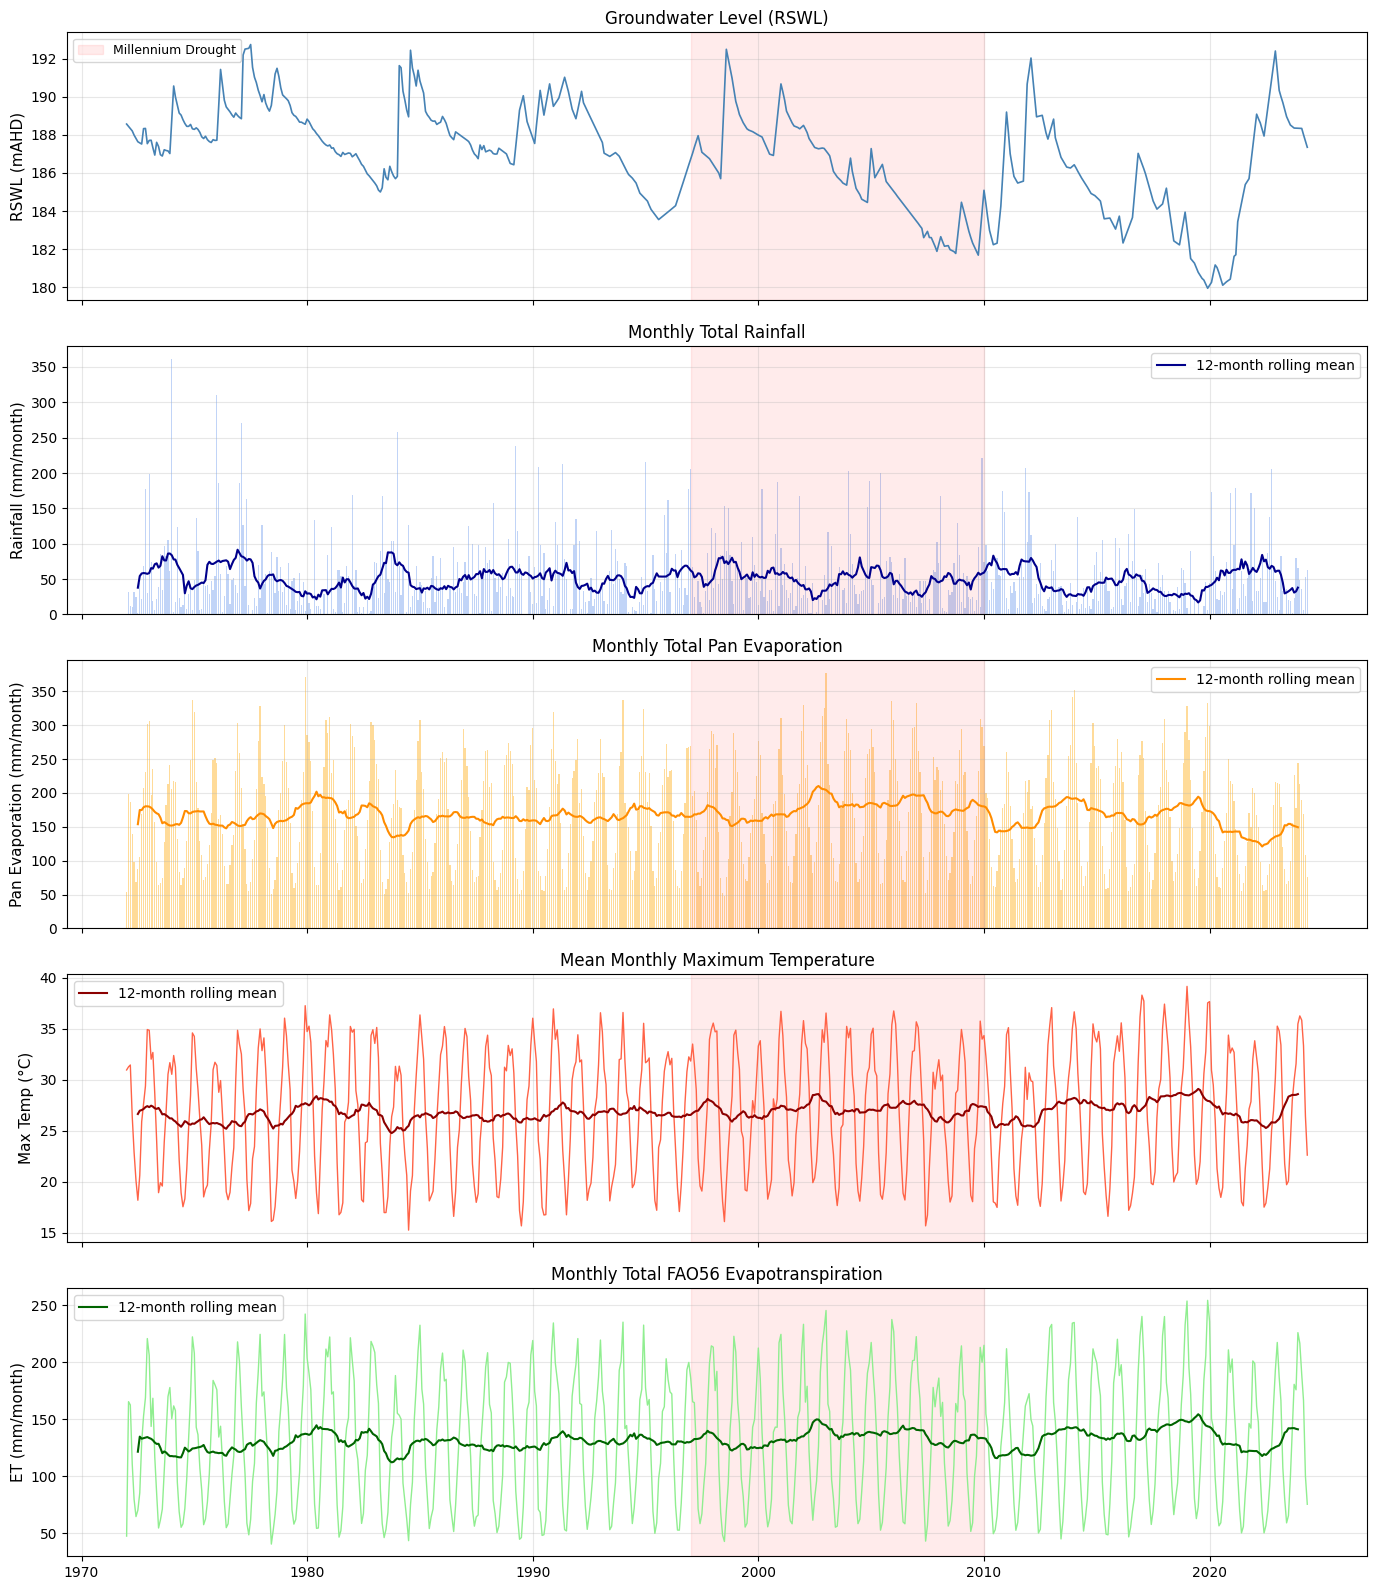

In [121]:
# Plot each variable on a timeseries axis
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Groundwater level
axes[0].plot(df.index, df['RSWL_mAHD'], color='steelblue', linewidth=1.2)
axes[0].set_ylabel('RSWL (mAHD)', fontsize=11)
axes[0].set_title('Groundwater Level (RSWL)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Rainfall
df['rainfall_12m'] = df['daily_rain'].rolling(window=12, center=True).mean() ## rolling mean
axes[1].bar(df.index, df['daily_rain'], width=20, color='cornflowerblue', alpha=0.4)
axes[1].plot(df.index, df['rainfall_12m'], color='darkblue', linewidth=1.5, label='12-month rolling mean')
axes[1].legend()
axes[1].set_ylabel('Rainfall (mm/month)', fontsize=11)
axes[1].set_title('Monthly Total Rainfall', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Pan Evaporation
df['evaporation_12m'] = df['evap_pan'].rolling(window=12, center=True).mean() ## rolling mean
axes[2].bar(df.index, df['evap_pan'], width=20, color='orange', alpha=0.4)
axes[2].plot(df.index, df['evaporation_12m'], color='darkorange', linewidth=1.5, label='12-month rolling mean')
axes[2].legend()
axes[2].set_ylabel('Pan Evaporation (mm/month)', fontsize=11)
axes[2].set_title('Monthly Total Pan Evaporation', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Max Temperature
df['max temp_12m'] = df['max_temp'].rolling(window=12, center=True).mean() ## rolling mean
axes[3].plot(df.index, df['max_temp'], color='tomato', linewidth=1.0)
axes[3].plot(df.index, df['max temp_12m'], color='darkred', linewidth=1.5, label='12-month rolling mean')
axes[3].legend()
axes[3].set_ylabel('Max Temp (°C)', fontsize=11)
axes[3].set_title('Mean Monthly Maximum Temperature', fontsize=12)
axes[3].grid(True, alpha=0.3)

# Evapotranspiration
df['evaptrans_12m'] = df['et_short_crop'].rolling(window=12, center=True).mean() ## rolling mean
axes[4].plot(df.index, df['et_short_crop'], color='lightgreen', linewidth=1.0)
axes[4].plot(df.index, df['evaptrans_12m'], color='darkgreen', linewidth=1.5, label='12-month rolling mean')
axes[4].legend()
axes[4].set_ylabel('ET (mm/month)', fontsize=11)
axes[4].set_title('Monthly Total FAO56 Evapotranspiration', fontsize=12)
axes[4].grid(True, alpha=0.3)
#axes[4].xaxis.set_major_locator(years)
#axes[4].xaxis.set_major_formatter(years_fmt)

# Shade the Millennium Drought period for reference across all panels (AI help)
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()



**Interpretation**: Distinct correlations are hard to determine from this plot, however a general increase in temperature and decrease in rainfall is evident across the Millenium Drought period. This appears to correlate to the decline in groundwater levels however further analysis is required to quantify this correlation.

### 3.2 Seasonal Decomposition
Isolate the signal using the Fourier Transform to compare seasonal cycles and multi-year variability for the primary variables (groundwater, rainfall and evaporation)
- seasonal component (12 months) isolates the annual cycle with, the amplitude of which indicates the intensity of the climate factors each year
-  multi-year component (> 2 years) isolates the long term variability that occurs to capture long wet or dry periods (such as the Millenium drought)

Note: these frequency plots have been produced with the 'period' on the x axis so that they can be more easily interpreted. This choice was made because these plots are primarily for introductory visualisation, not for more detailed analysis which would require plotting against 'frequency'.

#### Frequency Functions
Modified code from course

In [122]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

#### Groundwater Frequency Analysis

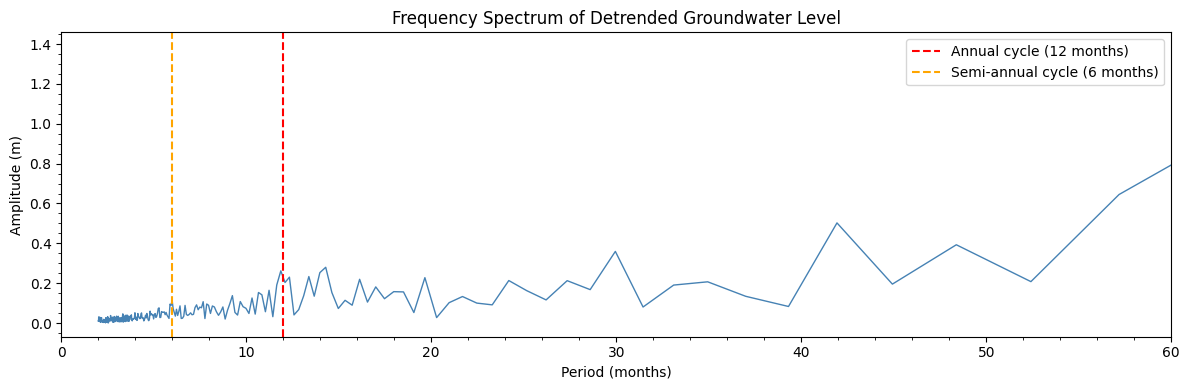

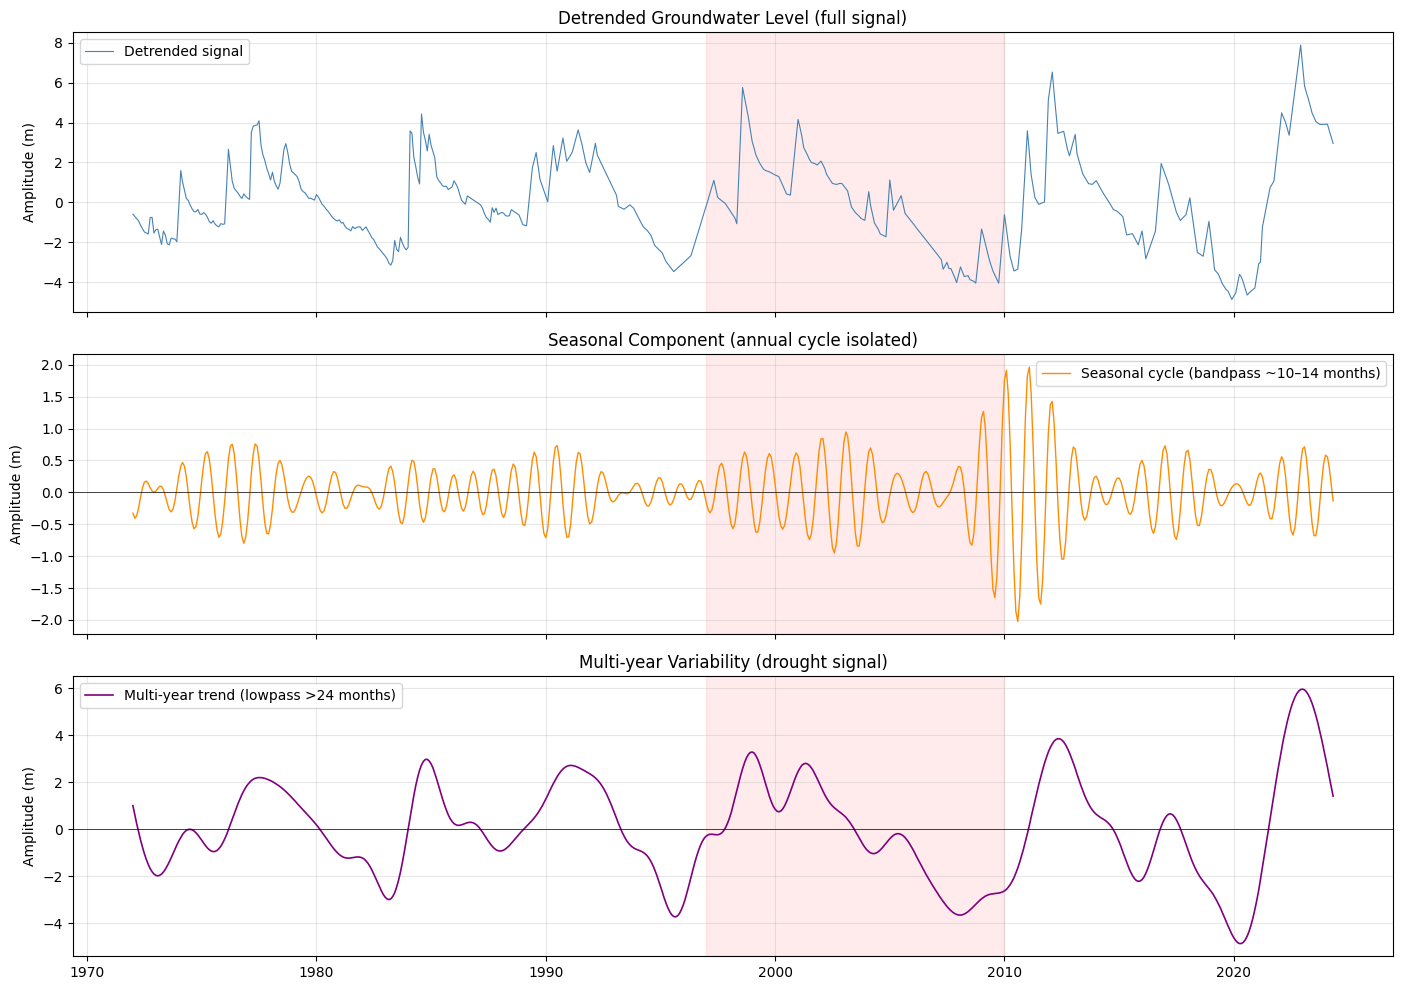

In [123]:
import numpy as np
import matplotlib.pyplot as plt
# AI help converting time and detrending data

# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['RSWL_mAHD'].values

# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit linear trend
trend = np.polyval(pp, time)
detrended = signal - trend

# From class content
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
periods = 1 / freqs[1:]
amps_plot = amps[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow a couple months on either sied
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Groundwater Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: The groundwater spectrum shows a weak annual peak, reflecting the slower timespan over which the aquifer responds to climactic changes. The multi-year variability plot is somewhat indicative of the known drought conditions with a wider negative dip from 2004 onwards however this plot doesn't definitively show this given it also captures longer trends.

#### Rainfall Frequency Analysis

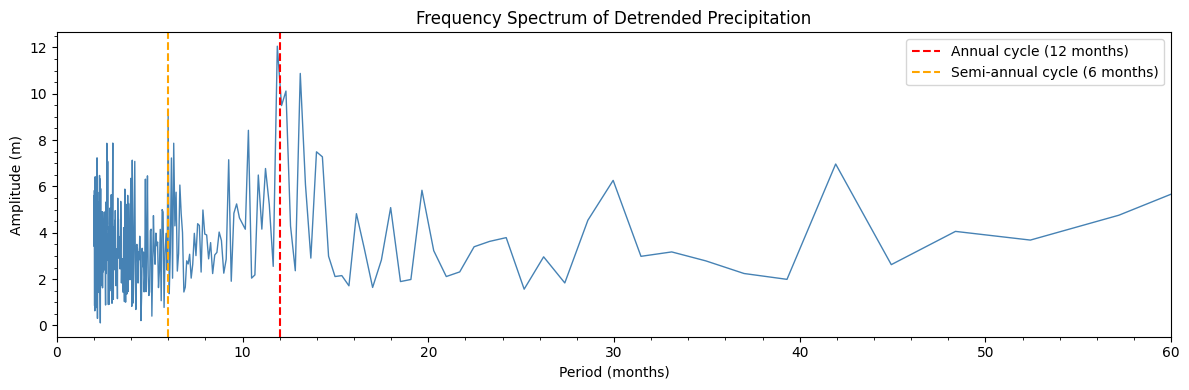

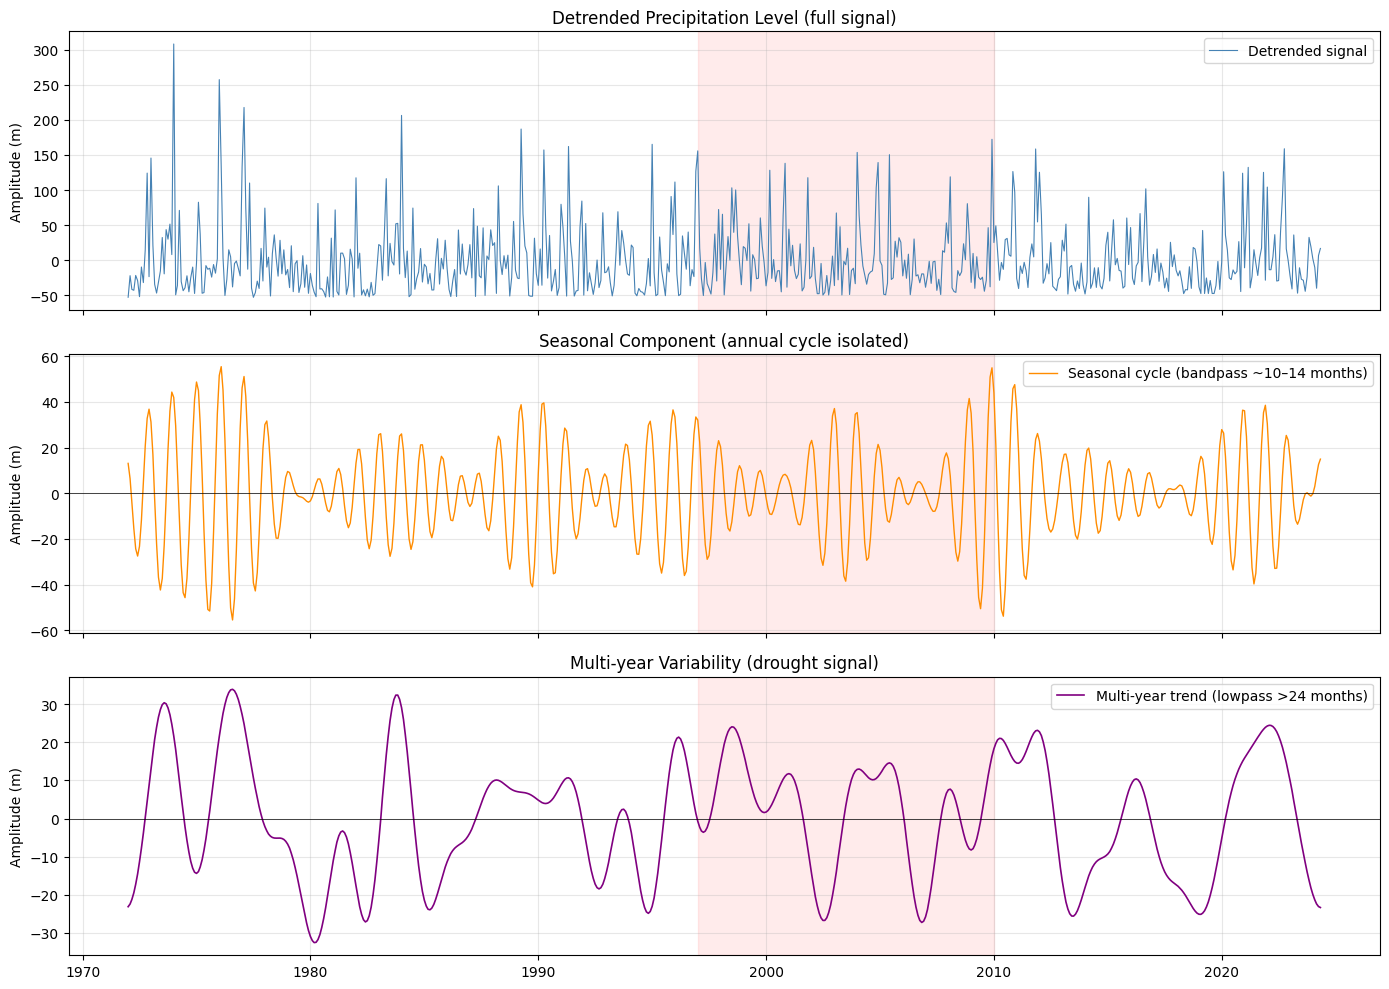

In [124]:
# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['daily_rain'].values

# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)
trend = np.polyval(pp, time)
detrended = signal - trend

freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
# Ignore the zero-frequency (DC) component at freqs[0]
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Precipitation')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Precipitation Level (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: The rainfall frequency decomposition exhibits a clear peak at 12 months, as is typical for rainfall patterns. The isolated components both support an understanding of drought conditions with smaller amplitude seasonal fluctuation and more consistently negative multi-year variability amplitude. After the drought (2010 year) there is a peak in the amplitude of seasonal rainfall which somewhat correlated to a similar peak in the groundwater plot, however there is a clear lag between the two motivating the cross correlation step below.

#### Evaporation Frequency Analysis

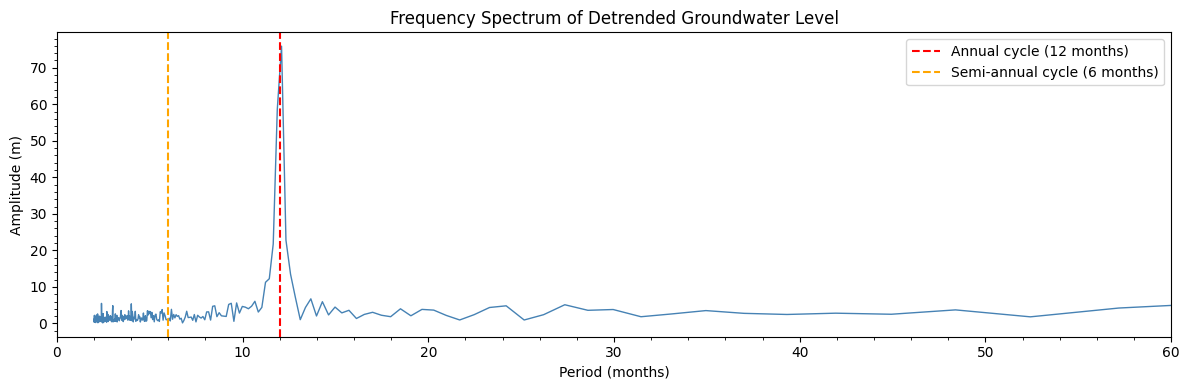

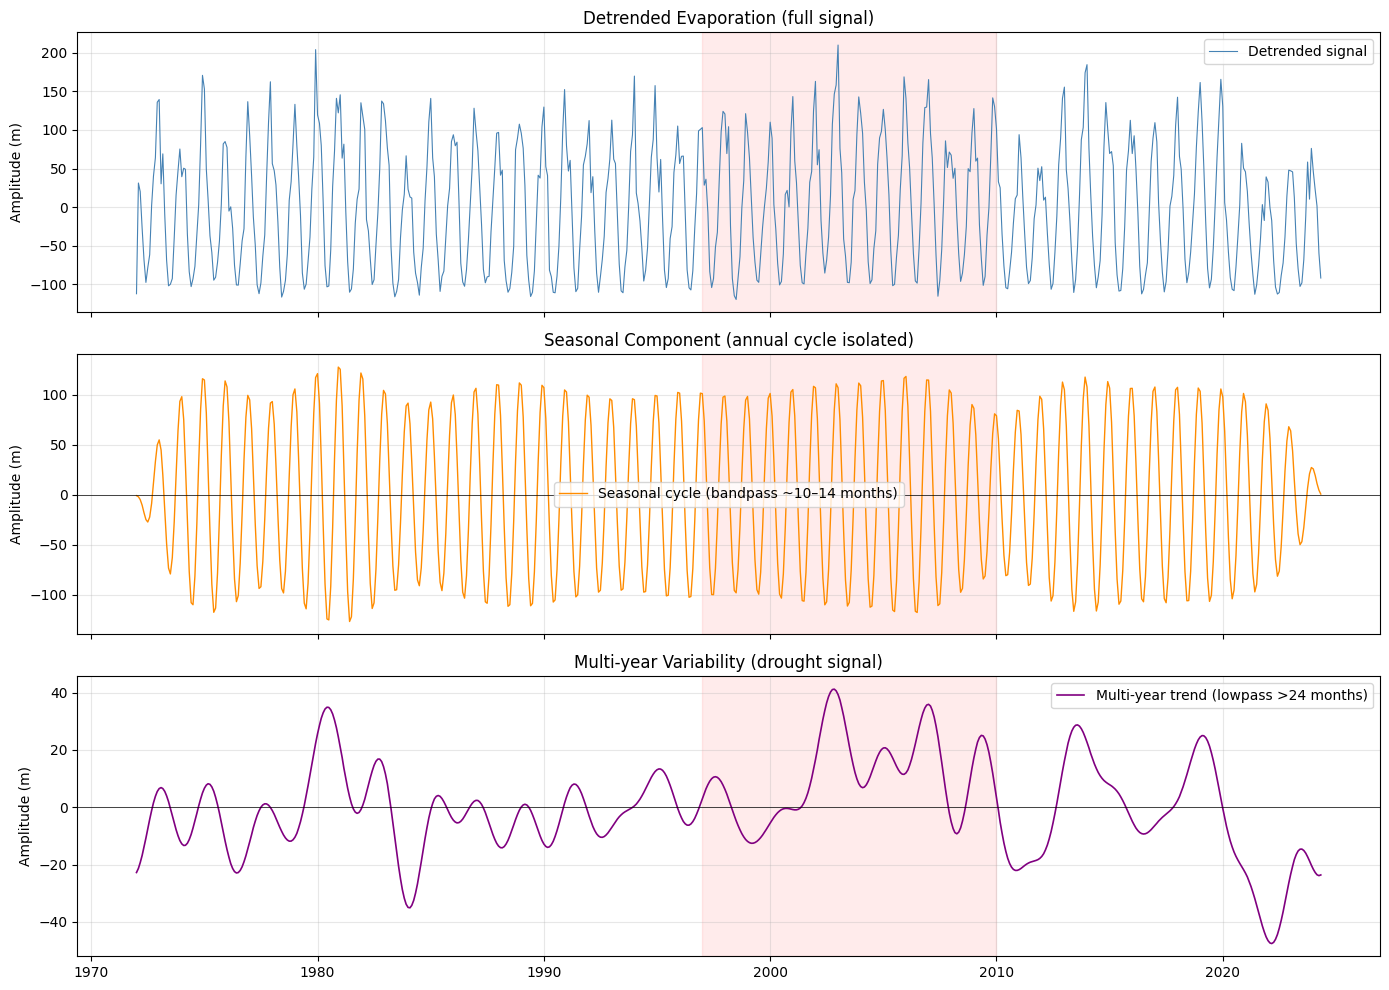

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Convert datetime index to numeric time axis (months since start)
time = np.arange(len(df))
signal = df['evap_pan'].values
# Fit and remove a linear trend (analogous to the Milankovitch example)
pp = np.polyfit(time, signal, 1)           # fit degree-1 polynomial (linear trend)
trend = np.polyval(pp, time)
detrended = signal - trend

# From your class code
freqs, amps = freq_spectrum(time, detrended)

# Convert frequency (cycles/month) to period (months) for labelling
periods = 1 / freqs[1:]    # period in months
amps_plot = amps[1:]        # matching amplitudes

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(periods, amps_plot, color='steelblue', linewidth=1)

# Mark physically meaningful periods for groundwater
ax.axvline(x=12,  color='red',    linestyle='--', label='Annual cycle (12 months)')
ax.axvline(x=6,   color='orange', linestyle='--', label='Semi-annual cycle (6 months)')

ax.set_xlabel('Period (months)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Frequency Spectrum of Detrended Groundwater Level')
ax.set_xlim([0, 60])      # focus on periods up to ~5 years
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

# Isolate the annual seasonal cycle using a bandpass filter
# Cutoff frequencies in cycles/month: annual = 1/12, allow ± a couple months
cutoff_seasonal = [1/14, 1/10]     # bandpass around the annual cycle

x_filt, y_seasonal = bandpass_filter(time, detrended, cutoff_seasonal)

# Isolate slow multi-year variability (e.g. drought cycles) using a lowpass filter
cutoff_lowpass = 1/24              # only keep cycles longer than 2 years

x_filt, y_lowpass = lowpass_filter(time, detrended, cutoff_lowpass)

# Plot detrended signal with both filtered components overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, detrended, color='steelblue', linewidth=0.8, label='Detrended signal')
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Detrended Evaporation (full signal)')
axes[0].legend()

axes[1].plot(df.index, y_seasonal, color='darkorange', linewidth=1, label='Seasonal cycle (bandpass ~10–14 months)')
axes[1].set_ylabel('Amplitude (m)')
axes[1].set_title('Seasonal Component (annual cycle isolated)')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()

axes[2].plot(df.index, y_lowpass, color='purple', linewidth=1.2, label='Multi-year trend (lowpass >24 months)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Amplitude (m)')
axes[2].set_title('Multi-year Variability (drought signal)')
axes[2].legend()

# Shade Millennium Drought on all panels
for ax in axes:
    ax.axvspan(pd.Timestamp('1997-01-01'), pd.Timestamp('2009-12-31'),
               alpha=0.08, color='red', label='Millennium Drought')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: Evaporation has the most distinct seasonal frequency peak and very little evident multi-year variability. As such the consistency of its cycles leaves little long term interpretation however it can be seen that during the Millenium Drought period there was a more positive peak in evaporation.

### 3.3 Cross Correlation

Frequency decomposition has shown that groundwater reacts to climate conditions at a slow rate with an distinct lag/time-offset. Hence cross correlation is required to quantify where the strongest relationship between the factors exists, this is important to make the data more realistic for use in regression correlation.

This method testes pearsons correlation coefficient between the groundwater and each climate variabls at lags of 0 to 36 month to identify the strongest absolute correlation. Note that this type of correlation check does not account for collinearity, an unavoidable effect of using interconnected climate data and the motivator for multi-variable regression in the next section.  


Note: AI help here to understand how to approach this cross correlation analysis

#### Rainfall Cross Correlation

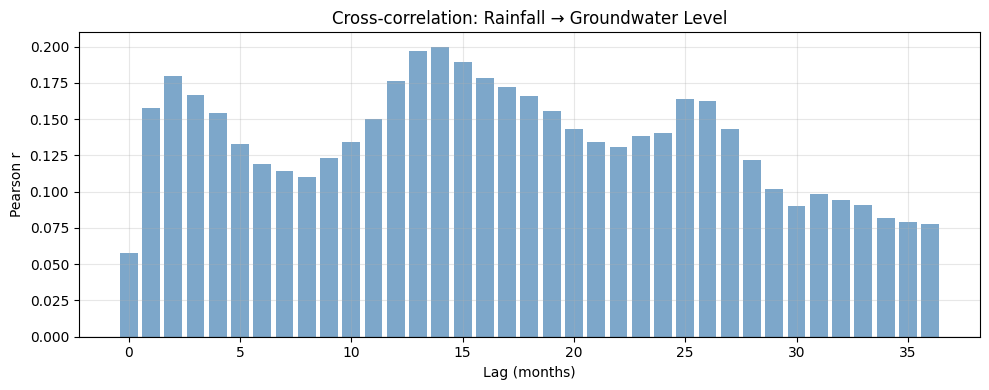

Strongest correlation at lag = 14.0 months, r = 0.200, p = 0.0000


In [126]:
from scipy import stats
import numpy as np

# Cross-correlation: determine how well rainfall at time t-lag predict groundwater at time t
max_lag = 36  # test up to 36 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['daily_rain'].dropna()

# Align on common index
aligned = df[['RSWL_mAHD', 'daily_rain']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['daily_rain'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['daily_rain'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Rainfall → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_rain = lag_df.loc[lag_df['r'].idxmax()]

best_lag_rain_months = int(best_lag_rain['lag_months'])

print(f"Strongest correlation at lag = {best_lag_rain['lag_months']} months, r = {best_lag_rain['r']:.3f}, p = {best_lag_rain['p_value']:.4f}")

####Evaporation Cross Correlation

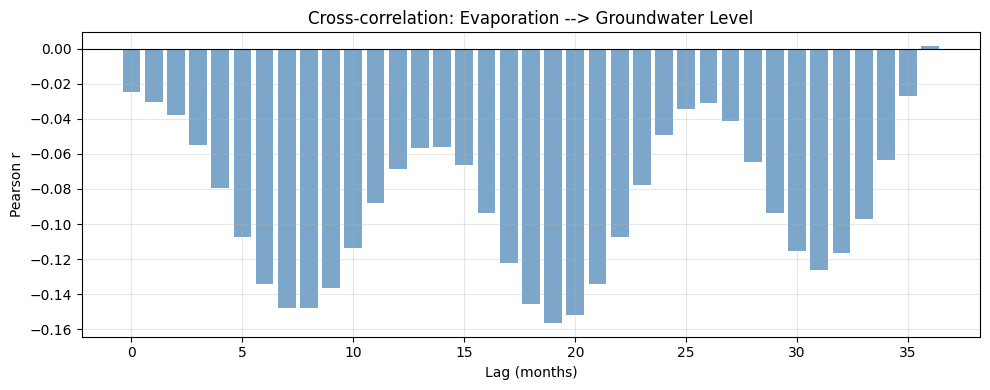

Strongest correlation at lag = 19.0 months, r = -0.156, p = 0.0001


In [127]:
# Cross-correlation: determine how well evaporation at time t-lag predict groundwater at time t
max_lag = 36  # test up to 24 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['evap_pan'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'evap_pan']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['evap_pan'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['evap_pan'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Evaporation --> Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_evap = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_evap_months = int(best_lag_evap['lag_months'])

print(f"Strongest correlation at lag = {best_lag_evap['lag_months']} months, r = {best_lag_evap['r']:.3f}, p = {best_lag_evap['p_value']:.4f}")

####Temperature Cross Correlation

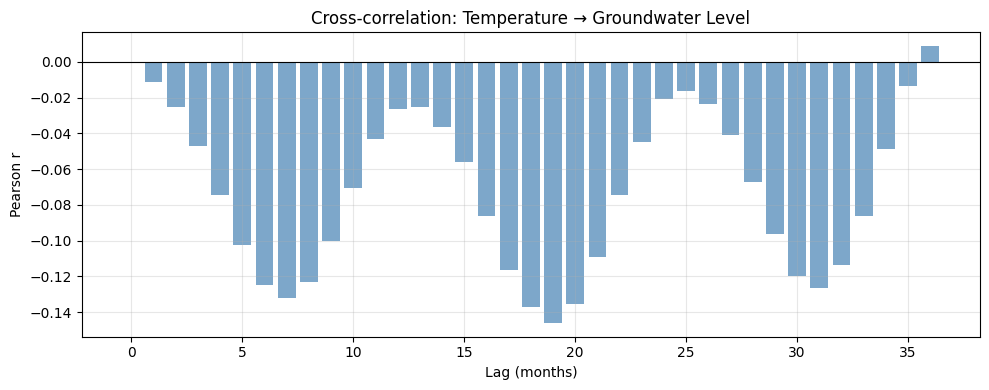

Strongest correlation at lag = 19 months, r = -0.146, p = 0.0003


In [128]:
# Cross-correlation: determine how well tempearture at time t-lag predict groundwater at time t
max_lag = 36  # test up to 36 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['max_temp'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'max_temp']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['max_temp'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['max_temp'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Temperature → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_temp = lag_df.loc[lag_df['r'].abs().idxmax()]

best_lag_temp_months = int(best_lag_temp['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp_months} months, "
      f"r = {best_lag_temp['r']:.3f}, "
      f"p = {best_lag_temp['p_value']:.4f}")

#### Evapotranspiration Cross Correlation

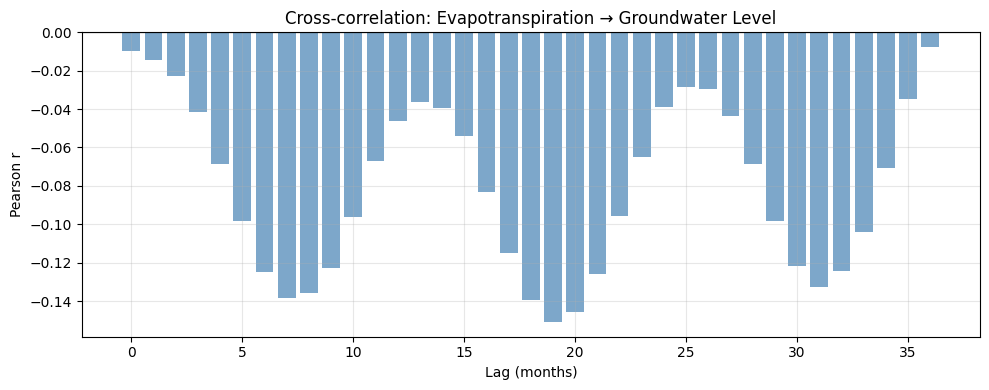

Strongest correlation at lag = 19.0 months, r = -0.146, p = 0.0003


In [129]:
# Cross-correlation: determine how well evapotranspiration at time t-lag predict groundwater at time t
max_lag = 36  # test up to 36 months lag

lags = range(0, max_lag + 1)
correlations = []

gw = df['RSWL_mAHD'].dropna()
rain = df['et_short_crop'].dropna()

# Align on common index first
aligned = df[['RSWL_mAHD', 'et_short_crop']].dropna()

for lag in lags:
    if lag == 0:
        r, p = stats.pearsonr(aligned['et_short_crop'], aligned['RSWL_mAHD'])
    else:
        r, p = stats.pearsonr(
            aligned['et_short_crop'].iloc[:-lag],
            aligned['RSWL_mAHD'].iloc[lag:]
        )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_months', 'r', 'p_value'])

# Plot the cross-correlation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lag_df['lag_months'], lag_df['r'], color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Evapotranspiration → Groundwater Level')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_lag_et = lag_df.loc[lag_df['r'].abs().idxmax()]
best_lag_et_months = int(best_lag_et['lag_months'])

print(f"Strongest correlation at lag = {best_lag_temp['lag_months']} months, r = {best_lag_temp['r']:.3f}, p = {best_lag_temp['p_value']:.4f}")

####Extract optimal lag and build lagged dataset
Consolidate the result from cross correlation and set up a lagged dataset for each parameter

In [130]:
print(f"Optimal lag — Rainfall:            {best_lag_rain_months} months")
print(f"Optimal lag — Evapotranspiration:  {best_lag_evap_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_temp_months} months")
print(f"Optimal lag — Max Temperature:     {best_lag_et_months} months")

Optimal lag — Rainfall:            14 months
Optimal lag — Evapotranspiration:  19 months
Optimal lag — Max Temperature:     19 months
Optimal lag — Max Temperature:     19 months


In [131]:
df_lagged = pd.DataFrame(index=df.index)

df_lagged['RSWL_mAHD'] = df['RSWL_mAHD']

# Shift each predictor back by its optimal lag: .shift(n) moves values forward n rows,
# so row t gets the value from t-n which means groundwater at t is paired with rainfall
#at t - lag (note: some AI support understanding how to use .shift)
df_lagged["rainfall_lagged"] = df['daily_rain'].shift(best_lag_rain_months)
df_lagged['evap_lagged']       = df['evap_pan'].shift(best_lag_evap_months)
df_lagged['temp_lagged']     = df['max_temp'].shift(best_lag_temp_months)
df_lagged['et_lagged']     = df['et_short_crop'].shift(best_lag_et_months)


# Drop rows where any lagged column is NaN
# (the first max_lag rows will be NaN due to shifting)
df_lagged = df_lagged.dropna()

print(f"\nLagged dataset shape: {df_lagged.shape}")
print(f"Date range: {df_lagged.index.min()} to {df_lagged.index.max()}")
print(df_lagged.head())


Lagged dataset shape: (610, 5)
Date range: 1973-08-01 00:00:00 to 2024-05-01 00:00:00
            RSWL_mAHD  rainfall_lagged  evap_lagged  temp_lagged  et_lagged
Date                                                                       
1973-08-01     186.89             24.4         54.3    30.962500       47.5
1973-09-01     187.22              1.6        197.8    31.268966      165.3
1973-10-01     187.18             43.8        186.7    31.448387      162.4
1973-11-01     187.16             21.6        139.2    26.403333      110.7
1973-12-01     187.02             68.1         98.4    22.900000       79.7


####Interpretation of Cross Correlation

**Interpretation of Cross Correlation**: Rainfall has the shortest lag with its strongest correlation at 14 months. Importantly this indicates that rainfall is the most direct recharge mechanism as the groundwater responds at a relatively faster rate. In contrast the other variables have lags of 19 months, supporting their indirect role in groundwater recharge/discharge. They modify the water balance of the system (eg. higher evapotranspiration leads to less infiltration resulting in reduced recharge) which causes the delay in comparison to the directly affecting rainfall.


In each cross correlation there are discrete and regular peaks with the second peak having the highest correlation in all cases. This occurs due to the strong seasonality across the variables, when the time is shifted these annual cycles aligna and misalign resulting in the repeated peaks and troughs at approximately every 12 months. Additionally the conistent peak on the second annual cycle in each plot can be explained physically by the recharge nature of the groundwater system: thick unsaturated zones and aquifers with large storage capacity result in recharge (or discharge) taking longer to infiltration and propagate throughout the aquifer, hence resulting in the slower response time of the second cycle.


#4. Analysis - Regression Correlation

Note: there is a brief interpretation under each plot, with the comprehensive interpretation in section 6

#####Install bambi

In [132]:
!pip install bambi #system command to install bambi package

In [133]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

###4.1 Single Regression (Rainfall)

Conduct a process similar to class code to investigate the single regression relationship between rainfall and groundwater.

From the cross correlation above (and physical understanding) rainfall was identified to have the primarly affect on regression. As such this single regression process can be used to determine the best model fit for the data (linear/quadratic etc.) so that more rigorous multi-variable regression can be used for all of the variables.  

Sample correlation r = 0.20
Sample correlation R^2 = 0.04


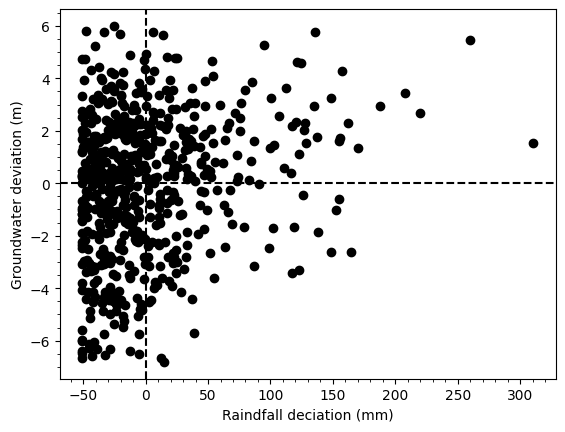

In [134]:
# Extract data for regression
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']


y = groundwater_level - np.mean(groundwater_level) #deviation in the x variable
x = rainfall_lagged - np.mean(rainfall_lagged) #deviation in the y variable
plt.plot(x,y,'ok') #plot the deviations
plt.gca().axvline(x=0, color = 'k', linestyle = '--') #add a vertical line at x=0
plt.gca().axhline(y=0, color = 'k', linestyle = '--') #add a horizontal line at y=0
plt.ylabel('Groundwater deviation (m)') #label the x-axis
plt.xlabel('Raindfall deciation (mm)') #label the y-axis
plt.minorticks_on() #include minor ticks

num = np.sum(x*y) #find the numerator
den = np.sqrt(np.sum(x**2)) * np.sqrt(np.sum(y**2)) #find the denominator
r = num/den #obtain r
print('Sample correlation r = {:.2f}'.format(r)) #print result to 2 d.p.
r2 = r**2
print('Sample correlation R^2 = {:.2f}'.format(r2)) #print result to 2 d.p.

Scale the x values

In [135]:
data = pd.DataFrame({"y": groundwater_level}) #define the y-variable
data["x_scaled"] = (rainfall_lagged-np.mean(rainfall_lagged)) / np.std(rainfall_lagged) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

Find the best fit polynomial

In [136]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False) # records logarithm of likelihood

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [137]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


           rank    elpd    p  elpd_diff  weight    se   dse  warning
linear        0 -1460.0  2.7        0.0     1.0  16.0  0.00    False
quadratic     1 -1460.0  3.4       -0.8     0.0  16.0  0.43    False
cubic         2 -1460.0  4.6       -2.0     0.0  16.0  1.20     True
quartic       3 -1460.0  4.8       -2.0     0.0  16.0  1.20    False


Plot the regression correlation with a linear model

Text(0, 0.5, 'Rainfall')

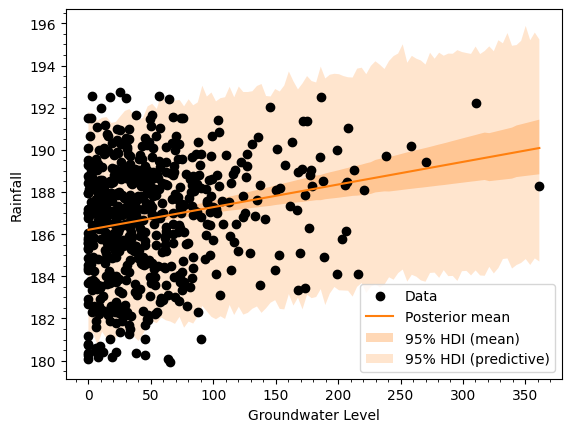

In [138]:
x_range = np.linspace(rainfall_lagged.min(), rainfall_lagged.max(), 100) # Predict across a range of distances values from 0 to 40
x_range_scaled = (x_range-np.mean(rainfall_lagged)) / np.std(rainfall_lagged) #we need to apply the same scaling as above

new_data = pd.DataFrame({"x_scaled": x_range_scaled}) #dataframe with the new x-values
model_linear.predict(idata_linear, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_linear.predict(idata_linear, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
#posterior_mean = y_pps_draws.mean(axis=0)
posterior_mean = y_mean_draws.mean(axis=0)
hdi_mean = az.hdi(
    y_mean_draws,
    prob=0.95, axis=0)
hdi_pps = az.hdi(
    y_pps_draws,
    prob=0.95, axis=0)

# Plot both posterior for regression lines and the observations
plt.plot(rainfall_lagged, groundwater_level, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Groundwater Level')
plt.ylabel('Rainfall')

**Interpretation**: The positive slope indicatesa correlation between increasing rainfall adn groundwater levels, this is physically expected. However the relationship is relatively weak with R^2 = 0.04 indicating that rainfall alone explains only 4% of groundwater variability. The significant scatter around the trend line indicates that rainfall is not the only control on groundwater and the broad uncertainty bands because groundwater responds slowly to rainfall and integrates many different climate factors hence doesn't have a direct response to individual rainfall events.

### 4.2 Multiple Regression

Multiple regression controls the other factors, allowing each variables independent contribution to be isolated

#### Standardise Data

In [139]:
# Standardise all variables to groundwater response (metres per one standard deviation increase)
groundwater_level = df_lagged['RSWL_mAHD']
rainfall_lagged = df_lagged['rainfall_lagged']
temp_lagged = df_lagged['temp_lagged']
evap_lagged = df_lagged['evap_lagged']
et_lagged = df_lagged['et_lagged']

# Response variable (groundwater)
data = pd.DataFrame({"y": groundwater_level})

# Standardised predictors
data["rain_scaled"] = (rainfall_lagged - np.mean(rainfall_lagged)) / np.std(rainfall_lagged)

data["temp_scaled"] = (temp_lagged - np.mean(temp_lagged)) / np.std(temp_lagged)

data["et_scaled"] = (et_lagged - np.mean(et_lagged)) / np.std(et_lagged)

data["evap_scaled"] = (evap_lagged - np.mean(evap_lagged)) / np.std(evap_lagged)

In [140]:
## Correlation Matrix
corr = data[[
    "rain_scaled",
    "temp_scaled",
    "et_scaled",
    "evap_scaled"
]].corr()

print(corr)

             rain_scaled  temp_scaled  et_scaled  evap_scaled
rain_scaled     1.000000    -0.221900  -0.189830    -0.187518
temp_scaled    -0.221900     1.000000   0.955880     0.942587
et_scaled      -0.189830     0.955880   1.000000     0.986231
evap_scaled    -0.187518     0.942587   0.986231     1.000000


**Interpretation**:

|r| < 0.5 → weak/moderate correlation

0.5–0.7 → significant correlation

0.7 → strong multicollinearity
- ET and evaporation are strongly correlated to temperature (physically plausible)
- Pan evaporation and ET strongly correlated because of their similar relationship to temperature
- hence this significant correlation requires multiple regression to isolate each variables independent contribution
---

####Multiple Regression Model

Direct extension of linear models discussed in class

In [141]:
model_multi = bmb.Model("y ~ rain_scaled + temp_scaled + et_scaled + evap_scaled",data)

idata_multi = model_multi.fit(idata_kwargs={"log_likelihood": True},progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


**Standardised Regression Coefficients**

In [142]:
# Extract coefficients
summary = az.summary(idata_multi,
    var_names=[
        "rain_scaled",
        "temp_scaled",
        "et_scaled",
        "evap_scaled"])

print(summary)

              mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
rain_scaled  0.496  0.109     0.32     0.67      1933      1422  1.00   
temp_scaled   0.18   0.37    -0.41     0.77      1570      1395  1.00   
et_scaled     0.22   0.75       -1      1.4      1076      1190  1.00   
evap_scaled  -0.72   0.65     -1.8     0.31      1049      1198  1.00   

            mcse_mean mcse_sd  
rain_scaled    0.0025  0.0018  
temp_scaled    0.0094  0.0066  
et_scaled       0.023   0.016  
evap_scaled      0.02   0.014  


**Interpretation**: These standardised regression coefficients indicate the independent  effects of each variable on groundwater after accouting for the other predictors. For example the rain_scaled mean = +0.49 indicates that one standard deviation increase in rainfall is associated with a 0.49m increase in groundwater after accounting for all the other predictors. As a result these coefficients are more defensible and reliable for this groundwater case, better than the pearson correlation coefficient and R^2 values.

**Pearson Correlation Coefficients**

In [143]:
# Pearson correlation variables
variables = {
    "Rainfall": rainfall_lagged,
    "Temperature": temp_lagged,
    "ET": et_lagged,
    "Pan evaporation": evap_lagged
}

for name, var in variables.items():

    x = groundwater_level - np.mean(groundwater_level)
    y = var - np.mean(var)

    r = np.sum(x*y) / (np.sqrt(np.sum(x**2)) * np.sqrt(np.sum(y**2)))

    print(f"{name}:")
    print(f"r = {r:.2f}")
    print(f"R² = {r**2:.2f}")
    print()

Rainfall:
r = 0.20
R² = 0.04

Temperature:
r = -0.15
R² = 0.02

ET:
r = -0.15
R² = 0.02

Pan evaporation:
r = -0.16
R² = 0.02



**Interpretation**: This Pearson correlation formula considers each variable independently ignoring the compounding effects of other variables. Hence is measures total association (including shared climatic effects), reducing its viability analysis in this project.

####Visualise Regression

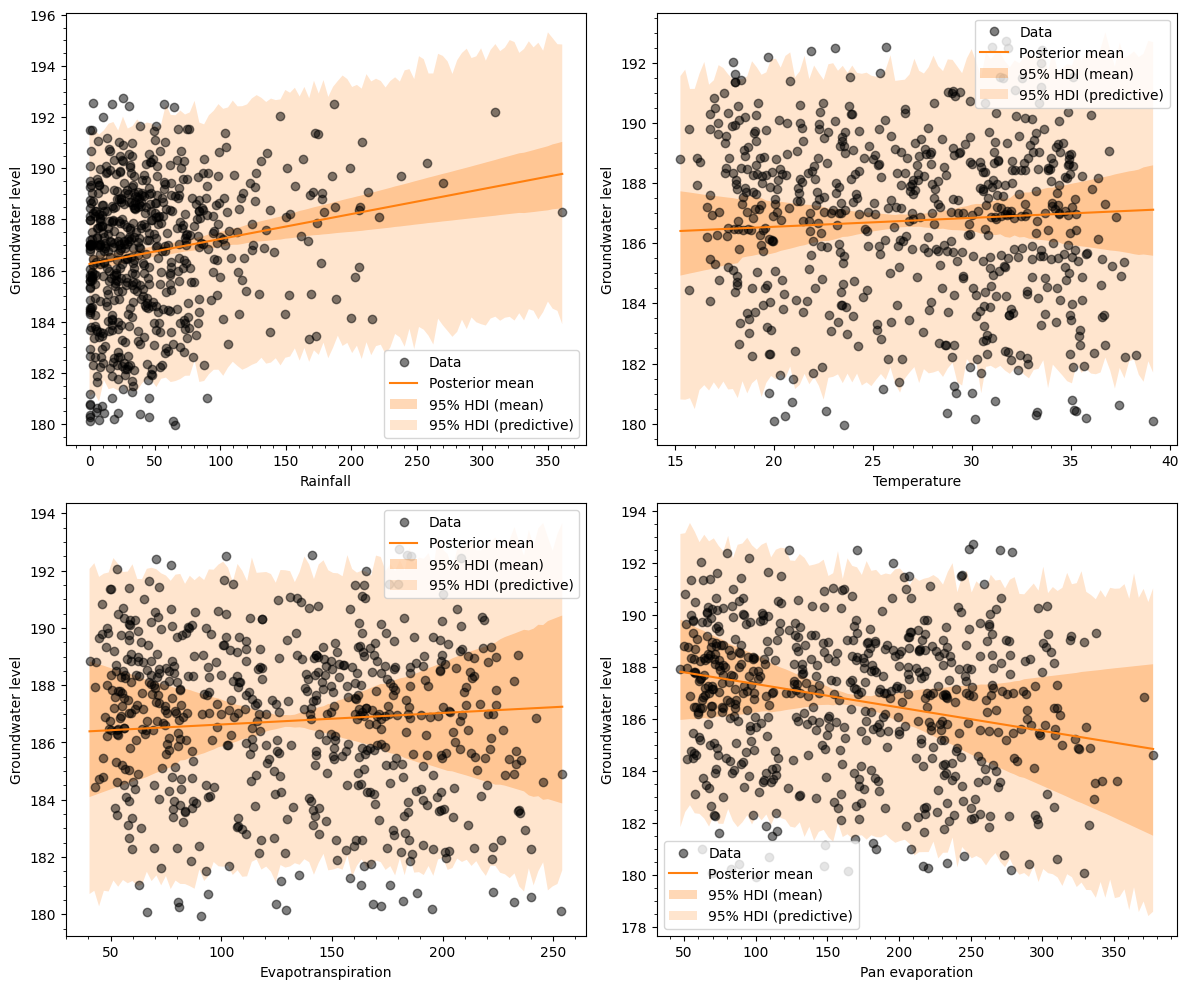

In [144]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictors = [
    ("rain_scaled", rainfall_lagged, "Rainfall"),
    ("temp_scaled", temp_lagged, "Temperature"),
    ("et_scaled", et_lagged, "Evapotranspiration"),
    ("evap_scaled", evap_lagged, "Pan evaporation")]

axes = axes.flatten()

##AI help to plot these regression models (to use for loop to optimise process)
for ax, (var_name, raw_data, label) in zip(axes, predictors):

    # Create prediction range for this variable
    x_range = np.linspace(raw_data.min(), raw_data.max(), 100)

    # Scale using same transformation as model fitting
    x_scaled = (
        x_range - np.mean(raw_data)
    ) / np.std(raw_data)

    # Hold all predictors at mean = 0
    new_data = pd.DataFrame({
        "rain_scaled": np.zeros(len(x_range)),
        "temp_scaled": np.zeros(len(x_range)),
        "et_scaled": np.zeros(len(x_range)),
        "evap_scaled": np.zeros(len(x_range))
    })

    # Vary only the predictor of interest
    new_data[var_name] = x_scaled

    # Generate predictions
    model_multi.predict(idata_multi,data=new_data,kind='response_params')

    model_multi.predict(idata_multi,data=new_data,kind='response')

    # Posterior draws
    y_mean_draws = idata_multi.posterior["mu"].values
    y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

    y_pps_draws = idata_multi.posterior_predictive["y"].values
    y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

    # Mean + HDI
    posterior_mean = y_mean_draws.mean(axis=0)

    hdi_mean = az.hdi(y_mean_draws,prob=0.95,axis=0)

    hdi_pps = az.hdi(y_pps_draws,prob=0.95,axis=0)

    # Plot observations
    ax.plot(raw_data, groundwater_level, 'ok', alpha=0.5, label="Data")

    # Posterior mean
    ax.plot(x_range,posterior_mean,color="C1",label="Posterior mean")

    # HDI mean
    ax.fill_between(x_range,hdi_mean[:, 0],hdi_mean[:, 1],alpha=0.3,color="C1",label="95% HDI (mean)",edgecolor=None)

    # Predictive HDI
    ax.fill_between(x_range,hdi_pps[:, 0],hdi_pps[:, 1],alpha=0.2,color="C1",label="95% HDI (predictive)",edgecolor=None)

    ax.legend()
    ax.set_xlabel(label)
    ax.set_ylabel("Groundwater level")
    ax.minorticks_on()

plt.tight_layout()
plt.show()

**Partial Regression Plots**:
- each pannel shows the relationship between groundwater and the variable after controlling for all other climatic variables, more powerful than seperate bivariate regression
- the HDI mean represents uncertainty in the regression line
- the HDI predictive represend uncertainty in future observations

#### Interpretation of Multiple Variable Regression:

**Standardised Regression Coefficients**
| Rainfall | Temperature | Evapotranspiration | Evaporation |
| --- | --- | --- | --- |
| +0.49 | +0.18 | +0.23 | -0.73 |

- these predictors have been standardaised so they are directly comparable: representing the groundwater response (in m) to one standard deviation increase in the predictor

Randfall
- clearest positive trend indicates rainfall is the strongest independent recharge control (one standard deviation increase in rainfall is associated with approximately a 0.49m standard deviation increase in groundwater level)
- large data spread remains, with HDI mean uncertainty interval increasing hence rainfall cannot fully explain groundwater change

Temperature
- weak correlation evident in nearly flat line
- highly uncertain interval that spans negative and positive values
- hence after accounting for evaporation, ET and rainfall the temperature contributes little independently which reflects the multicollinearity of this system
- temperature influences groundwater indirectly through the other factors, as such will not be included in the water balance model

Evapotranspiration
- weak positive slope, a surprising result as ET would be typically thought to reduce groundwater (intercepting infiltration and reducing recharge)
- likely occurns because ET is strongly correlated with rainfall seasonality and the multiple regression struggles to seperate it
- the extremely wide uncertainty interval confirms this instability

Pan Evaporation
- strongest negative relationship indicated evaporation is a dominant groundwater loss mechanism
- reflects physical understanding that higher evaporative demands reduces groundwater use
- uncertainty is large however the negative trend is meaningful

**Pearson Correlations**
| Rainfall | Temperature | Evapotranspiration | Evaporation |
| --- | --- | --- | --- |
| +0.2 | -0.15 | -0.15 | -0.16 |
- weak with R^2 between 0.02 - 0.04
- indicates that no simple climatic variable strongly explains groundwater independently

**Overall**

Pearson correlation correlation: shared association between two variables
- overall climatic association

Standardised (multiple regression) correlation coefficient: indepdendent effect of predictor after controlling for other factors
- isolates independent groundwater contribution showing that rainfall is the dominant recharge and evaporation is the dominant discharge
- however in the cases of temp and ET multicollinearity limits interpretation of individual climatic predictors

**Application to model**

- Multiple regression coefficients are more appropriate for weighting factors in the groundwater storage model
- Temperature will not be included in the model due to its indirect affects

#5. Model Creation

### 5.1 Concept

The basic model concept for the storage in a groundwater system is $$ΔS=Recharge−Discharge$$

this will be implemented month by month (n = new, o = old)
$$storage_n = storage_o + ΔS$$

Components of recharge include:
- rainfall
  - via infiltration (percolation and interflow)
- stream loss (into groundwater system)

Components of discharge include:
- ET and evaporation loss (in a shallow unconfined aquifer system these factors remove water directly from saturated soil/shallow aquifers)
  - evapotranspiration (capillary rise)
  - evaporation (induced upwelling and removing rainfal before it can infiltrate into groundwater system)
- pumping (usually for agricultural purposes)
- baseflow (flow from aquifer to stream)

Note: due to lack of available information regarding stream loss and inflow to this particular bore I am considering this factor negligible but this is a limitation to broader applicability.

---
To convert storage to height we can use the specific yield (how much water must be added/removed to change the groundwater level)

$$Δh=​ΔS/S_y​$$
where:
| Variable | Description |
| --- | --- |
| $$Δh$$ | groundwater level change |
| $$ΔS$$ | storage change |
| $$S_y$$ | specific yield |


Note: it will be important here to convert from units of storage (mm) to height (m)

---
**Variables**

Specific Yield: the volume of water added.removed to raise/lower the water table by 1m: for the Narrabri formation (where the bore is located) this is between 0.05 - 0.3 (DCCEEW, 2025)

Recharge Fraction: the fraction of rainfall that becomes groundwater recharge (ie. the amount that infiltrates)

---

Set up data frame to run through model:

In contrast to class examples this model will require the data I've been using to run through each month - this is because the climate factors are highly variable and a general trendline would impact the models accuracy.

In [145]:
## Model Data Frame
model_data = pd.DataFrame({
    "groundwater": groundwater_level,
    "rainfall": rainfall_lagged,
    "et": et_lagged,
    "temp": temp_lagged,
    "evap": evap_lagged
}).dropna()

## Set coefficient weights (from regression above)
rain_coef = 0.49
temp_coef = 0.18
et_coef = 0.23
evap_coef = -0.73

Visualisation of regression coefficients

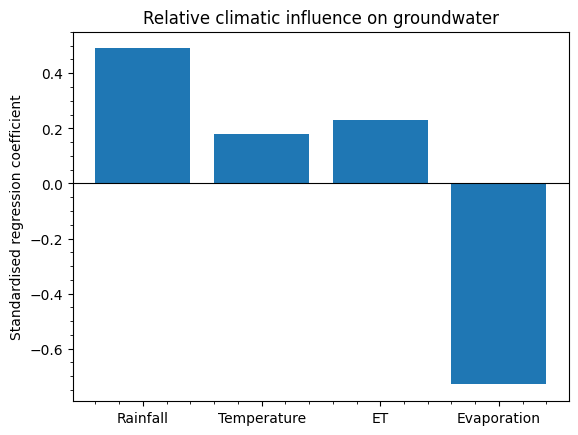

In [146]:
drivers = ["Rainfall", "Temperature", "ET", "Evaporation"]
coefficients = [rain_coef, temp_coef, et_coef, evap_coef]

plt.bar(drivers, coefficients)
plt.axhline(0, color="k", linewidth=0.8)
plt.ylabel("Standardised regression coefficient")
plt.title("Relative climatic influence on groundwater")
plt.minorticks_on()
plt.show()

### 5.2 Simple Model Function

In [147]:
recharge_weight = abs(rain_coef)
discharge_weight = abs(et_coef) + abs(evap_coef)

print(recharge_weight)
print(discharge_weight)

0.49
0.96


Simple groundwater model

Note: AI used to help me understand how to allow the data to contribute to the step model (ie. help to modify the concept from the soil model to include data points)

In [148]:
# Set up the groundwater model as a function so that it can be run with varied inputs in the analysis steps
def run_groundwater_model(data, recharge_fraction, specific_yield):

    # Integrate data into the model
    rainfall = data["rainfall"].values
    et = data["et"].values
    evap = data["evap"].values
    observed_gw = data["groundwater"].values

    # Start model at observed initial groundwater level
    groundwater_model = []
    gw = observed_gw[0]

    groundwater_model.append(gw)

    for step in range(1, len(data)):

        # Recharge term: fraction of rainfall becomes recharge
        recharge = recharge_fraction * rainfall[step] * recharge_weight

        # Climate discharge term: ET and evaporation remove water
        discharge = recharge_fraction * (
            et[step] * abs(et_coef) +
            evap[step] * abs(evap_coef)
        )

        # Change in storage, in mm
        delta_storage_mm = recharge - discharge

        # Convert storage change to groundwater level change, in metres
        delta_gw_m = (delta_storage_mm / 1000) / specific_yield

        # Update groundwater level
        gw = gw + delta_gw_m
        groundwater_model.append(gw)
        # this is the equivalend of T = T_new, T_output.append(...)

    return np.array(groundwater_model)

Test model run

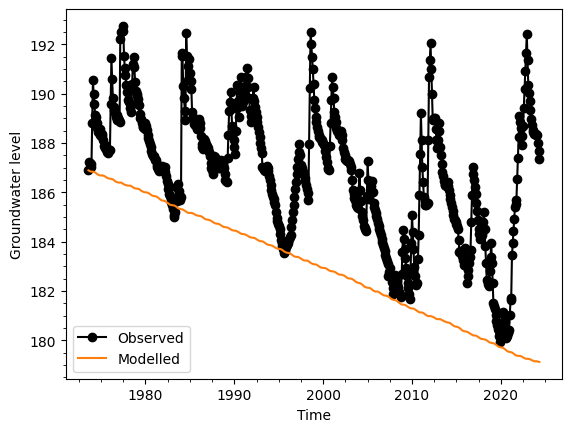

In [149]:
recharge_fraction = 0.01
specific_yield = 0.1

gw_modelled = run_groundwater_model(
    model_data,
    recharge_fraction,
    specific_yield
)

plt.plot(model_data.index, model_data["groundwater"], 'ok-', label="Observed")
plt.plot(model_data.index, gw_modelled, color="C1", label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.legend()
plt.minorticks_on()
plt.show()

### 5.3 Calibrate Model Parameters

To determine the best recharge fraction and specific yield for this model to fit the given data

**RMSE and R^2**

These are calculated parameters used to compare the model to observed data:

RMSE is the root mean square error

- measures the typical difference between the modelled and observed groundwater level
- a smaller RMSE correlates to a better model (eg. RMSE = 4.5 means the model is typically wrong by 4.5m)

R^2 measures how much of the observed variation is explained by the model
- the closer the 1 indicates a better model fit

**Calibrate Model**:

Simple nested for loop structure to compare different parameter values (values for recharge fraction and specific yield). For each set of values used in the model, it will find the RMSE and run through all combinations until the RMSE is minimised


In [150]:
recharge_values = np.linspace(0.001, 0.05, 50) # 0.1 to 5% of rainfall becomes recharge (reasonable where runoff and evaporation are high)
specific_yield_values = np.linspace(0.05, 0.3, 50) # 5 to 30% for an unconfined alluvial aquifer

# AI help understanding how to initialise these parameters
best_rmse = np.inf
best_recharge = None
best_sy = None
best_model = None

for recharge_fraction in recharge_values:

    for specific_yield in specific_yield_values:

        gw_modelled = run_groundwater_model(model_data,recharge_fraction,specific_yield)

        observed = model_data["groundwater"].values
        rmse = np.sqrt(np.mean((observed - gw_modelled)**2))

        if rmse < best_rmse:
            best_rmse = rmse
            best_recharge = recharge_fraction
            best_sy = specific_yield
            best_model = gw_modelled

observed = model_data["groundwater"].values

r = np.corrcoef(observed, best_model)[0, 1]
best_r2 = r**2

print(f"Best recharge fraction = {best_recharge:.3f}")
print(f"Best specific yield = {best_sy:.3f}")
print(f"Best RMSE = {best_rmse:.3f}")
print(f"Best R² = {best_r2:.3f}")

Best recharge fraction = 0.004
Best specific yield = 0.213
Best RMSE = 2.567
Best R² = 0.274


**Interpretation**:
The calibrated recharge fraction prepresents the proportion of rainfall that contributes to modelled groundwater level change. The result indicates approximately 0.4% of rainfall becomes effective recharge in this model. This percentage is low it can be physically plausible in the Lower Namoi regio. Climate data reports that evaporation exceeds rainfall by 3x each month hence most rainfall is lost to evaporation/ET (DCCEEW, 2025). Additionally the simplified nature of the model does not control for many factors that contribute to this low value: recharge is episodic and delayed, groundwater is deep, etc.

The specific yield fraction is physically reasonable for this region, Sy = 0.21 as it sits within the 0.05-0.3 range for the specific Namoi region (DCCEEW, 2025). Being on the higher end of this range indicates that the same water input causes smaller groundwater rise compared to a lower Sy result. Hence this indicates the modelled water table responds slowly and has a large storage capacity. Combined with the small recharge fraction this overall calibration shows that the system has small recharge but effective water storage, tending to dampen the groundwater response.

However the calibrated recharge fraction and specific yield are not independently constrained by the model and should only be interpreted as effective calibration parameters rather than direct field estimates.

### 5.4 Plot Best Model against Observations

The visualise the overal model against the observed data in order to examine its overall accuracy and viability for observations

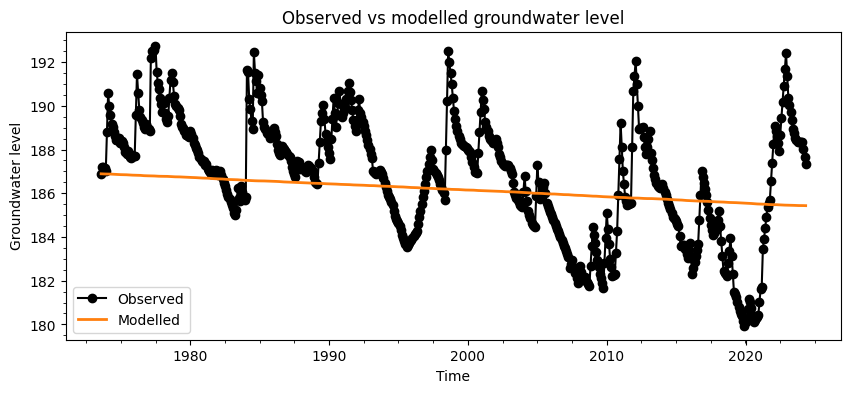

In [151]:
plt.figure(figsize=(10, 4))

plt.plot(model_data.index, model_data["groundwater"], 'ok-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", linewidth=2, label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Observed vs modelled groundwater level")
plt.legend()
plt.minorticks_on()
plt.show()

In [152]:
observed = model_data["groundwater"].values

rmse = np.sqrt(np.mean((observed - best_model)**2))
r = np.corrcoef(observed, best_model)[0, 1]
r2 = r**2

print(f"Final RMSE = {rmse:.3f}")
print(f"Final R² = {r2:.3f}")

Final RMSE = 2.567
Final R² = 0.274


**Interpretation**: This shows the that the model follows the general declining trend evident in the groundwater data. Hence using the combination of climactic data with scaling weights from multiple regression produces a fairly realistic simple model.

The calibrated model produced RMSE = 2.57 m and R² = 0.27 indicates that the model captures broad groundwater trends, but not short-term variability due to the various omitted factors. Given the variable depth range of the groundwater level is approximately 12m, the 2.5m uncertainty doesn't prevent the model from showing the long term trends but lessens the ability for highly accurate prediction.

### 5.5 Simple Scenarios

To understand how similar variation in the climatic parameters will affect the simple model

20% rainfall reduction

In [153]:
scenario_dry = model_data.copy()
scenario_dry["rainfall"] = scenario_dry["rainfall"] * 0.8

gw_dry = run_groundwater_model(scenario_dry,best_recharge,best_sy)

20% evaporation and evapotranspiration increase

In [154]:
scenario_hot = model_data.copy()
scenario_hot["evap"] = scenario_hot["evap"] * 1.2
scenario_hot["et"] = scenario_hot["et"] * 1.2

gw_hot = run_groundwater_model(scenario_hot,best_recharge,best_sy)

Plot to visualise the simple scenarios

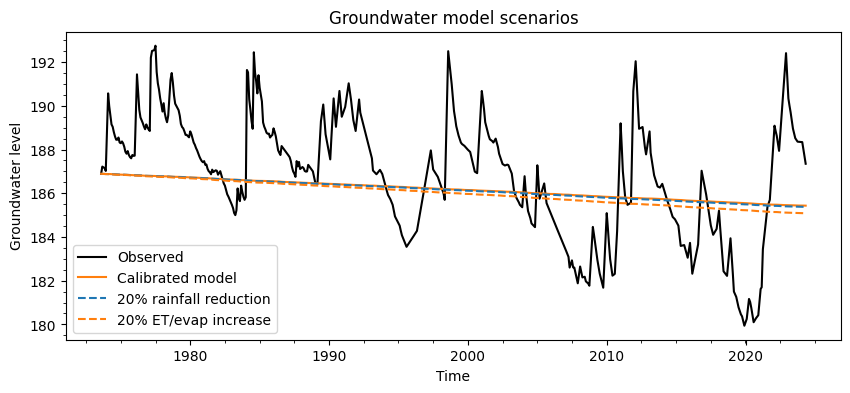

In [155]:
plt.figure(figsize=(10, 4))

plt.plot(model_data.index, model_data["groundwater"], 'k-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", label="Calibrated model")
plt.plot(model_data.index, gw_dry, '--', label="20% rainfall reduction")
plt.plot(model_data.index, gw_hot, '--', label="20% ET/evap increase")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model scenarios")
plt.legend()
plt.minorticks_on()
plt.show()

**Interpretation**: these simple scenarios show the differing affects of a change in rainfall and evaporation to the model. The important observation is that a change by 20% in evaporation/ET has a more significant impact on the ground water level than a 20% change in rainfall. This further supports prior findings that evaporation has a stronger impact in this region.



### 5.6 Millennium Drought Scenario

To use the model to examine what climatic shifts occured over the Millenium Drought period


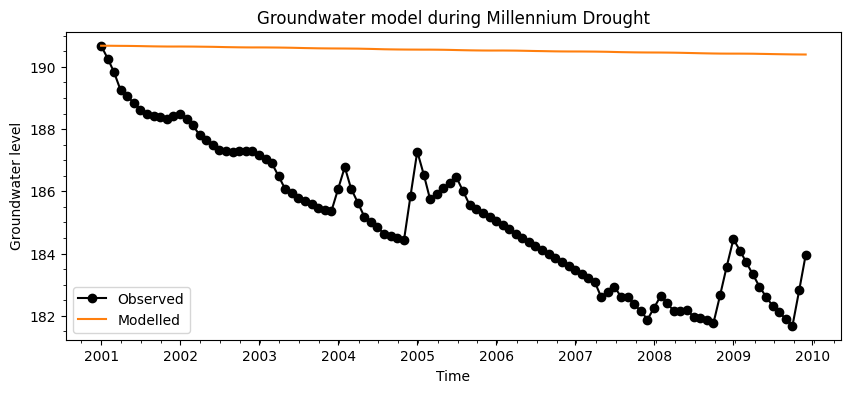

In [156]:
# Limit the model data to the Millenium Drought time period (peak drought occurred from 2001 to 2009)
model_data.index = pd.to_datetime(model_data.index)
drought_data = model_data.loc["2001":"2009"].copy()

gw_drought = run_groundwater_model(drought_data,best_recharge,best_sy)
plt.figure(figsize=(10, 4))

plt.plot(drought_data.index, drought_data["groundwater"], 'ok-', label="Observed")
plt.plot(drought_data.index, gw_drought, color="C1", label="Modelled")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model during Millennium Drought")
plt.legend()
plt.minorticks_on()
plt.show()

In [157]:
# Compare teh drought mean to the full mean to determine the change in variables as attributed by this model
full_mean = model_data[["rainfall", "et", "evap"]].mean()
drought_mean = drought_data[["rainfall", "et", "evap"]].mean()

change_percent = 100 * (drought_mean - full_mean) / full_mean

print(change_percent)

rainfall   -6.223644
et          3.557116
evap        7.992653
dtype: float64


**Interpretation**: This model attributes drought groundwater changes to the following climatic factors:
- 6.2% rainfall below average
- 8% evaporation above average
- 3.6% evapotranspiration above average
This observed rainfall reduction is less than the 10-20% decline that was reported across southeast Australia during the Millennium Drought, suggesting that the Namoi region experienced a relatively mild rainfall deficit.
The significantly higher increase in evaporation and evapotransportation suggests the evaporation factor may have had a stronger control on groundwater decline, this links to the strength of the regression coefficient (-0.71). As a result this system is driven more by enhanced discharge/evaporative demand than by rainfall collapse alone, a unique response to drought conditions.

The simple water balance model substantially underestimates the groundwater decline over this Millennium Drought period, only predicting a small decrease despite observed groundwater levels declining by 9m between 2001 and 2009. This indicates that climactic forcing is insufficient to explain the groundwater trends in the shorter term drought period, showing that the model only captures broad trends. This is likely due to several shorter term and highly variable processes that are not included in the simple model (such as lateral groundwater flow and heterogenity of the aquifer composition). Hence despite regression modelling showing that rainfall and evaporation have statistically significant correlation to groundwater variability, this drought simulation shows that those factors alone cannot explain the groundwater decline.




### 5.7 Pumping Model

Extraction of groundwater for human uses (such as agricultural irrigation) can contribute to the discharge in the water balance model

Add a pumping term to the model in mm/month

In [158]:
def run_groundwater_model_pumping(data, recharge_fraction, specific_yield, pumping_rate=0):

    rainfall = data["rainfall"].values
    et = data["et"].values
    evap = data["evap"].values
    observed_gw = data["groundwater"].values

    groundwater_model = []
    gw = observed_gw[0]

    groundwater_model.append(gw)

    for step in range(1, len(data)):

        recharge = recharge_fraction * rainfall[step] * recharge_weight

        climate_discharge = (et[step] * abs(et_coef) +evap[step] * abs(evap_coef))

        discharge = recharge_fraction * climate_discharge + pumping_rate # add pumping term to discharge

        delta_storage_mm = recharge - discharge

        delta_gw_m = (delta_storage_mm / 1000) / specific_yield

        gw = gw + delta_gw_m

        groundwater_model.append(gw)

    return np.array(groundwater_model)

Run a calibration including pumping term (include one more loop in the same calibration method as above)

In [159]:
recharge_values = np.linspace(0.001, 0.05, 30)
specific_yield_values = np.linspace(0.05, 0.3, 30)
pumping_values = np.linspace(0, 15, 21)

best_rmse = np.inf
best_recharge = None
best_sy = None
best_pumping = None
best_model = None

for recharge_fraction in recharge_values:

    for specific_yield in specific_yield_values:

        for pumping_rate in pumping_values:

            gw_modelled = run_groundwater_model_pumping(model_data,recharge_fraction,specific_yield,pumping_rate)

            observed = model_data["groundwater"].values
            rmse = np.sqrt(np.mean((observed - gw_modelled)**2))

            if rmse < best_rmse:

                best_rmse = rmse
                best_recharge = recharge_fraction
                best_sy = specific_yield
                best_pumping = pumping_rate
                best_model = gw_modelled

observed = model_data["groundwater"].values

r = np.corrcoef(observed, best_model)[0, 1]
best_r2 = r**2

print(f"Best recharge fraction = {best_recharge:.3f}")
print(f"Best specific yield = {best_sy:.3f}")
print(f"Best pumping rate = {best_pumping:.1f} mm/month")
print(f"Best RMSE = {best_rmse:.3f}")
print(f"Best R² = {best_r2:.3f}")

Best recharge fraction = 0.003
Best specific yield = 0.145
Best pumping rate = 0.0 mm/month
Best RMSE = 2.567
Best R² = 0.274


**Interpretation**: introducing pumping as an adittional calibration parameter did not improve the model performance (RMSE and R^2 remain unchanged) as the optimum pumpin rate was determined to be 0 mm/month. This indicates that this aquifer is primarily controlled by climatic/natural system variation alone, any pumping influence is not evident with a simple pumping term. The slightly altered recharge fraction (0.3%) and specific yield (0.145) remain plausible indicating moderate storage capacity and low rainfall contribution.

As such this pumping model can be used to investigate how groundwater would change if constant extraction had been operating over the entire record. It shows that in reality there was no constant pumping signal required to explain the behaviour, setting this up as a baseline for future pumping scenario investigation.

#### Pumping Scenarios

This imagines what the groundwater trend would look like if constant extraction operated over the record

Scenario: groundwater extraction for irrigation
- conservative estimate of 2–3 mm/month equivalent represents typical stock and domestic use across the bore's approximate capture zone (back-calculated from the NSW water sharing plan's 88,255 ML annual extraction limit divided across the aquifer area, very broad estimate)

- liberal estimate of 8–10 mm/month represents peak irrigation demand periods, consistent with the report's description of seasonal drawdowns of tens of metres under pumping stress


In [160]:
scenario_pump = model_data.copy()

gw_pump1 = run_groundwater_model_pumping(scenario_pump,best_recharge,best_sy,pumping_rate=2.5)

gw_pump2 = run_groundwater_model_pumping(scenario_pump,best_recharge,best_sy,pumping_rate=9)

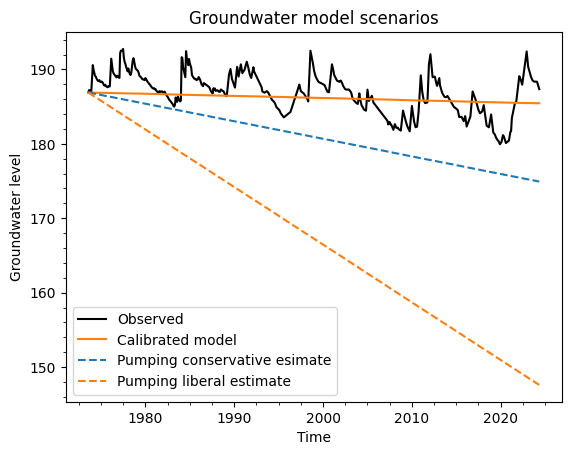

In [161]:
plt.plot(model_data.index, model_data["groundwater"], 'k-', label="Observed")
plt.plot(model_data.index, best_model, color="C1", label="Calibrated model")
plt.plot(model_data.index, gw_pump1, '--', label="Pumping conservative esimate")
plt.plot(model_data.index, gw_pump2, '--', label="Pumping liberal estimate")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Groundwater model scenarios")
plt.legend()
plt.minorticks_on()
plt.show()

**Interpretation**: The intense variation from the observed groundwater trends shows the significant impact of constant pumping on this aquifer system. This modelling is largely limited as it doesn't account for groundwater depletion and variable pumping rates but it generally shows that even a conservative esimtate over the 50 year time period would have resulted in significant decline and potential depletion of the aquifer.

### 5.8 Future Scenarios
Can we use this model to predict how the groundwater system will behave into the future?

Using a simple approach to take recent climate averages and applying different scenario multipliers in order to estimate future trends.

In [162]:
#Model up to 30 year (limit of credibility)
future_years = 30
future_steps = future_years * 12 # monthly steps

Use average of last 10 years as the baseline for extrapolation

In [163]:
recent_data = model_data.loc["2010":].copy()

baseline_rain = recent_data["rainfall"].mean()
baseline_et = recent_data["et"].mean()
baseline_evap = recent_data["evap"].mean()
baseline_gw = model_data["groundwater"].iloc[-1]

# Create a dataframe for the future data (AI help)
future_dates = pd.date_range(
    start=model_data.index[-1] + pd.DateOffset(months=1),
    periods=future_steps,freq="MS")

future_data = pd.DataFrame(index=future_dates)

future_data["groundwater"] = baseline_gw
future_data["rainfall"] = baseline_rain
future_data["et"] = baseline_et
future_data["evap"] = baseline_evap

Set up a function that takes change factors and linearises them into the future dataframe (AI help here to fix errors/issues)

In [164]:
def make_future_scenario(rainfall_change_total, et_change_total, evap_change_total):

    trend = np.linspace(0, 1, len(future_dates))

    future_data = pd.DataFrame(index=future_dates)

    future_data["groundwater"] = baseline_gw

    future_data["rainfall"] = baseline_rain * (1 + rainfall_change_total * trend)
    future_data["et"] = baseline_et * (1 + et_change_total * trend)
    future_data["evap"] = baseline_evap * (1 + evap_change_total * trend)

    return future_data

Set up model scenarios

In [165]:
# low impact (minimial drying, factors changed by 0.05)
scenario_low = make_future_scenario(rainfall_change_total=-0.05,et_change_total=0.05,evap_change_total=0.05)

# medium impact (moderate drying, factors changed by 0.2)
scenario_med = make_future_scenario(rainfall_change_total=-0.20,et_change_total=0.20,evap_change_total=0.20)

# high impact (severe drying, factors changed by 0.4)
scenario_high = make_future_scenario(rainfall_change_total=-0.40,et_change_total=0.40,evap_change_total=0.40)

In [166]:
# Without pumping scenarios
gw_low = run_groundwater_model(scenario_low, best_recharge, best_sy)
gw_med = run_groundwater_model(scenario_med, best_recharge, best_sy)
gw_high = run_groundwater_model(scenario_high, best_recharge, best_sy)

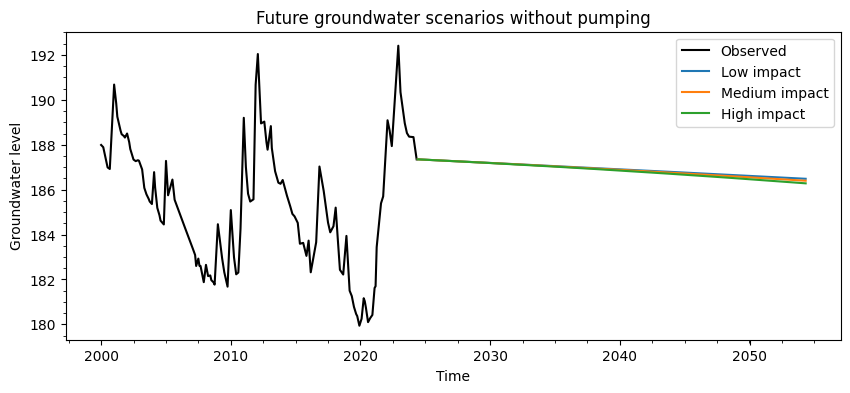

In [167]:
# Plot scenarios without pumping
plt.figure(figsize=(10, 4))

# Focus on the last 25 years for better resolution of future data
recent_observed = model_data.loc["2000":]

plt.plot(recent_observed.index, recent_observed["groundwater"], 'k-', label="Observed")
plt.plot(scenario_low.index, gw_low, label="Low impact")
plt.plot(scenario_med.index, gw_med, label="Medium impact")
plt.plot(scenario_high.index, gw_high, label="High impact")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Future groundwater scenarios without pumping")
plt.legend()
plt.minorticks_on()
plt.show()

In [168]:
# With pumping scenarios
gw_low_pump = run_groundwater_model_pumping(scenario_low, best_recharge, best_sy, pumping_rate=2) # conservative estimate
gw_med_pump = run_groundwater_model_pumping(scenario_med, best_recharge, best_sy, pumping_rate=5) # modest estimate
gw_high_pump = run_groundwater_model_pumping(scenario_high, best_recharge, best_sy, pumping_rate=10) # liberal esimate

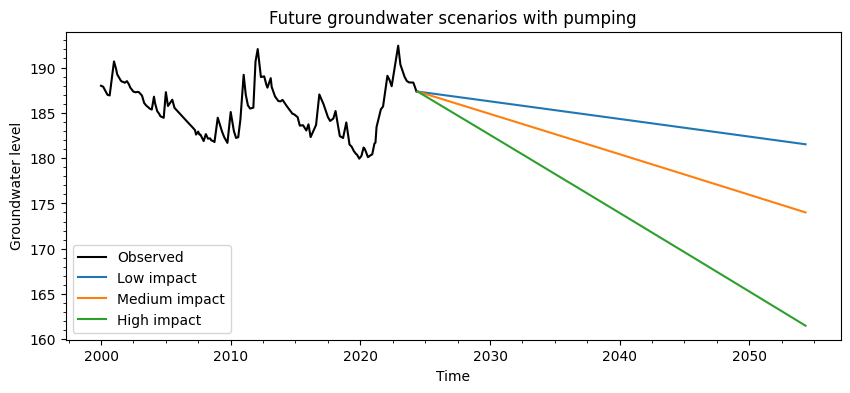

In [169]:
# Plot scenarios with pumping
plt.figure(figsize=(10, 4))

# Focus on the most recent 15 years for better resolution of future data
recent_observed = model_data.loc["2000":]

plt.plot(recent_observed.index, recent_observed["groundwater"], 'k-', label="Observed")
plt.plot(scenario_low.index, gw_low_pump, label="Low impact")
plt.plot(scenario_med.index, gw_med_pump, label="Medium impact")
plt.plot(scenario_high.index, gw_high_pump, label="High impact")

plt.xlabel("Time")
plt.ylabel("Groundwater level")
plt.title("Future groundwater scenarios with pumping")
plt.legend()
plt.minorticks_on()
plt.show()

**Interpretation**: Calibration has shows that historical groundwater trends are primarily controlled by climate while this future scenario modelling shows the sensitivity of groundwater levels to extraction when pumping is introduced.

Without pumping the low, medium and high impact climate scenarios produce only minor divergence over the 30 year future period. With a modest (~1m) decline across the scenarios this shows that the calibrated climate model is relatively insensitive to plausible future climatic changes.
However the addition of pumping estimates causes substantially faster groundwater decline, significantly separating the scenarios across the 30 year period. This suggests pumping is an amplifier of climatic trends, essentially increasing the sensitivity of the aquifer to climate stress.

Hence the future sustainability of groundwater in the region depends more on extraction rates than climate change alone.

#6. Interpretation


**Climatic Controls on Groundwater**

Frequency and cross-correlation analyses demonstrated that groundwater responds to climatic trends over relatively long timescales (14–19 months), indicating substantial storage and delayed recharge processes occur within the aquifer. Rainfall exhibited the shortest lag (14 months), this supports its role as the primary recharge mechanism. While evaporation and evapotranspiration exhibited longer lags (19 months), reflecting their indirect control on groundwater through modification of the water balance.

The simple correlation between groundwater and individual climatic variables were weak (R² = 0.02–0.04), indicating that no single climate variable independently explains groundwater behaviour. However multiple regression revealed that rainfall is the dominant recharge control (β = +0.49) and pan evaporation is the dominant discharge control (β = −0.73). This suggests groundwater variability is a result of the interaction between atmospheric demand (evaporation) and water inputs (rainfall) rather than either individual climatic factor.

**Overall Hydrogeological Insights**

The delayed groundwater response and relatively high calibrated specific yield indicate that the Lower Namoi alluvial aquifer has a significant storage capacity and responds slowly to climatic changes.
The calibrated rainfall recharge fraction (~0.4%) indicates only a small proportion of rainfall contributes to groundwater level change within the model. This is consistent with the semi-arid climate of the region where evaporation exceeds rainfall by approximately threefold and most rainfall is lost before reaching the water table (DCCEEW, 2025). Ultimately, the strong negative influence of evaporation links to the vulnerability of shallow unconfined aquifers to increasing atmospheric water demand such as under drought and climate warming conditions.


**Millennium Drough Insights**

The Millennium Drought provided a natural case for examining groundwater response to prolonged climatic stress.
The model found that while rainfall during the drought was only ~6% below average, evaporation increased by ~8% and evapotranspiration by ~4%, indicating that enhanced evaporative demand was a more important control on groundwater decline than rainfall reduction alone at this bore site. This differs somewhat from the broader southeast Australian drought trends that focus on rainfall deficits rather than evaporative processes.

**Model Performance**

The calibrated water balance model reproduced the broad long-term groundwater trend despite using only rainfall, evaporation and evapotranspiration as climatic inputs.
Model performance (RMSE ≈ 2.6m, R^2 ≈ 0.27) indicates that climate explains a meaningful but incomplete proportion of groundwater variability, particularly explaining variability that occurs over a long term period.
The inability of the model to reproduce the full Millennium Drought decline suggests that additional processes such as delayed recharge, groundwater flow and aquifer heterogeneity influence groundwater levels over shorter timescales.


**Limitations/Uncertainty**

There are many limitations across the modelling process for this project, they each result in uncertainties that limit the scalability of the model findings.
- The model assumes constant recharge fraction snd specific yield through time, however both parameters would typically vary seasonally and spatially
- The model cannot represent spatial variability in recharge, storage and groundwater flow of the aquifer - more extensive physical modelling and research would have to be undertaken to improve this.
- Climate variables are aggregated to monthly timesteps, potentially masking short-duration recharge events and extreme rainfall periods
- Pumping was represented as a constant extraction term and therefore does not capture variability in irrigation demand
- Multiple regression coefficients are affected by multicollinearity between temperature and evapotranspiration, limiting interpretation of their individual effects
- Many components of the aquifer system are not included due to lack of data/required information, some of these include: aquifer geometry, groundwater flow laterall, pumping records, soil moisture storage, river-aquifer interaction, etc.

## Conclusion
Ultimately through the combination of data analysis methods this project has examined the climactic factors that influence groundwater fluctuations and used modelling to produce past and future groundwater scenarios.

**Research Question 1**

The time series and frequency analysis exhibited general trends across both groundwater and climactic variables, indicating that climate has an influence. Cross correlation analysis identified delayed groundwater responses of 14-19 months, confirming rainfall as the most direct recharge mechanism. Simple regression demonstrated no individual climatic variable strongly explains groundwater variablility while multiple regression showed rainfall is the dominant recharge driver and pan evaporation is the dominant discharge driver.
Groundwater fluctuations are therefore generally controlled by the balance between rainfall recharge and evaporative losses and in the Namoi region the evaporative losses are more significant to groundwater fluctuations than rainfall recharge.

**Research Question 2**

Regression coefficients were incorporated into a simple water balance model to link the climate impacts to groundwater storage change. The calibration of the model produced a physically realistic recharge fraction and specific yield values and reproduced broad groundwater trends that demonstrate climate explains a significant component of groundwater variability over the long term.
Future scenario analysis showed that pumping significantly amplifies  the long-term groundwater decline due to climate change alone, however has not been the primary driver of decline in the past. Therefore a simple data-driven water balance model can be used to reproduce long term groundwater behaviour and provide a tool to investigate future climate and management scenarioes but is not a fully predictive hydrogeological model due to its many limitations.



Overall this project analysis demonstrates that groundwater levels in the Lower Namoi are primarily controlled by climatic processes, particularly evaporation discharge and rainfall recharge. Simple climae and groundwater datasets can be used to construct a long term physically accurate groundwter model that can be used to identify the primarily climatic controls, aquifer properties and future scenarios. The sustainability of future groundwater reserves relies on models such as this to inform management and ensure longevity.

---
# 7. Reflection

Project Topic

While thinking about potential project topics I considered what prior knowledge could help me contextualise a question. I noticed over the course of the group projects that the more difficult ones coincided with an overly complex problem/topic that would have required significant prior understanding to better understand what could be done with the data. Hence I reflected on a water science course I did in the summer and considered the concept of groundwater modelling. Groundwater reserves have significant importance to Australia as one of the main drivers of agricultural systems, so data analysis is extremely important in understanding how these systems can be managed. This was an excellent opportunity to independently manage a larger coding project from start to finish.

Engagement with Content

On reflection of this course I found I engaged more meaningfully when I switched to handwritten notes, as it helped me fully process the content. Though at first I had difficulty committing techniques from the content to memory, I found throughout this project that the learning is more focused on developing scientific and statistical reasoning to understand how coding can be used to investigate an issue. This project provided experience interpreting outputs and designing analyses that extended course content. I also learnt a lot from the use of AI, particularly the importance of asking clear questions and checking outputs against my own understanding.

Key Decisions and Changes
Bore Selection

I originally selected a random bore site in the Namoi region, however I later found the Lower Namoi hydrogeological conceptual model report which provided context on the geology of the region. From this report I selected borehole GW030170 because its unconfined aquifer geology lends itself to documenting climatic variations, the main goal of this project. This was not intended to improve the results but to allow for stronger interpretation and modelling. This emphasised the importance of developing a contextual understanding of a dataset.

Cross Correlation

I initially considered directly comparing climate variables with groundwater but realised the delayed response would be misleading. I used AI to help work through this problem and checked my understanding with Dave. Understanding cross-correlation became a useful learning opportunity and allowed me to better apply the dataset to this specific question.

Regression Modelling

I started with a single variable regression model between rainfall and groundwater, however the weak results and interconnected nature of climatic variables highlighted the impact of collinearity. I therefore extended the analysis to a multiple regression case, finding it was a simple extension of course content. Importantly, this step became essential because the resulting coefficients were used to build the groundwater model.

Modelling Section

This came together much more simply than I expected. Once I figured out how to integrate the climate data into the model, the remaining construction was relatively straightforward due to the simplified recharge equations being used. The RMSE and R^2 techniques were not something I originally considered, but they provided a useful way to quantitatively evaluate model performance. Overall, this model helped me develop an appreciation for the trade-off between model simplicity and real-world application.

Impact of Class Feedback and Presentations

The class presentations were a valuable experience, acting as a reality check to ensure my project was understandable. Explaining my code helped me identify strong and weak areas of analysis and highlighted assumptions that I had not fully explained to a general audience (such as explaining the reasons for pumping and the physical properties of unconfined aquifers). Discussing projects with classmates was also really interesting in understanding the many different ways of implementing course content.